# Gestalt 3D Experiment with Rerun Visualization

This notebook runs the gestalt experiments with interactive 3D visualization using Rerun.

In [1]:
# these current hyperparameter settings work decently well for scene 00
# may have to go back to locking the initial first frame gibbs, or first two frame Gibbs

In [2]:
# Import the algorithm-only experiment module (no rerun dependencies)
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
sys.path.append('/home/esli/GenParticles_neural_stimulus')

from gestalt_experiment_algorithm import *

In [3]:
# TODO: fixing the scales is going to be surprisingly hard, and should be done tomorrow 

## Configuration

Set up experiment parameters and paths.

In [4]:
# Display current configuration
print(f"Experiment Name: {EXPERIMENT_NAME}")
print(f"Save Directory: {EXPERIMENT_SAVE_DIR}")
print(f"Hyperparameters: {HYPERPARAMS}")
print(f"Scenes: {GESTALT_SCENES}")
print(f"Textures: {GESTALT_TEXTURES}")

Experiment Name: Gestalt_3D_Experiment_Algorithm_Only
Save Directory: /home/esli/GenParticles_neural_stimulus
Hyperparameters: {'number_of_blobs': 64, 'number_of_hyperblobs': 3, 'num_seeded_runs': 3}
Scenes: ['scene_00000', 'scene_00001']
Textures: ['texture_00', 'texture_07', 'texture_13', 'texture_16']


## Load and Visualize Sample Data

Load data for a single scene/texture combination to inspect the data quality.

In [5]:
# Load sample data
sample_scene = 'scene_00000'
sample_texture = 'texture_00'

try:
    depth, flow = load_gestalt_data(sample_scene, sample_texture)
    print(f"Loaded data for {sample_scene}_{sample_texture}")
    print(f"Depth shape: {depth.shape}")
    print(f"Flow shape: {flow.shape}")
    
    # Compute 3D points and motion
    points_3d, motion_3d = compute_3d_points_and_motion(depth, flow)
    print(f"3D points shape: {points_3d.shape}")
    print(f"3D motion shape: {motion_3d.shape}")
    
except Exception as e:
    print(f"Error loading sample data: {e}")

Loaded data for scene_00000_texture_00
Depth shape: (90, 1000, 1000)
Flow shape: (89, 520, 960, 2)
Downsampling from 1000 to 96 (factor: 8)
Valid motion vectors: 799596/820224 (97.49%) with magnitude <= 2.0
Error loading sample data: too many values to unpack (expected 2)


## Interactive Exploration

Use this cell to interactively explore specific combinations or modify parameters.

In [6]:
# ========================================
# STEP 0: Configuration
# ========================================
explore_scene = 'scene_00001'
explore_texture = 'texture_00'
custom_hyperparams = {
    "number_of_blobs": 50,
    "number_of_hyperblobs": 5,
    "num_seeded_runs": 1,
}

print(f"Configuration for {explore_scene}_{explore_texture}")
print(f"Hyperparams: {custom_hyperparams}")

Configuration for scene_00001_texture_00
Hyperparams: {'number_of_blobs': 50, 'number_of_hyperblobs': 5, 'num_seeded_runs': 1}



=== STEP 1: Loading data for scene_00001_texture_00 ===
✓ Depth shape: (90, 1000, 1000)
✓ Flow shape: (89, 520, 960, 2)
✓ Depth range: [2.00, 4.61], mean: 3.23


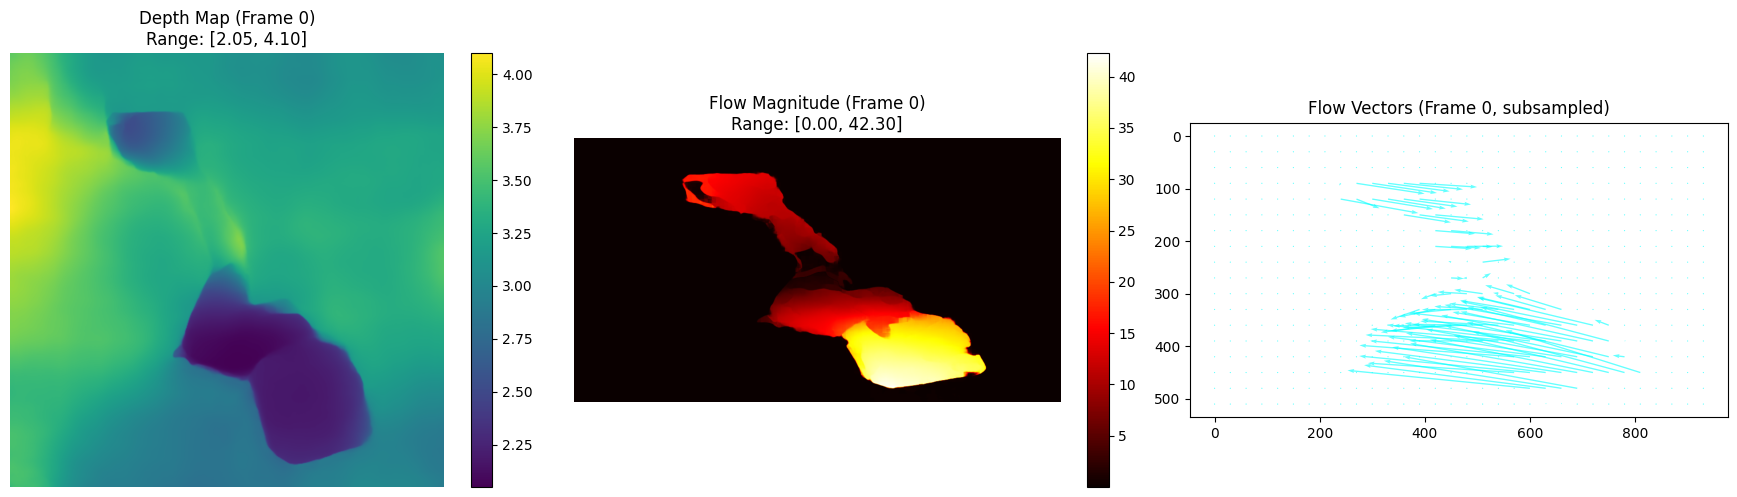

In [7]:
# ========================================
# STEP 1: Load Raw Data
# ========================================
print(f"\n=== STEP 1: Loading data for {explore_scene}_{explore_texture} ===")

depth, flow = load_gestalt_data(explore_scene, explore_texture)
print(f"✓ Depth shape: {depth.shape}")
print(f"✓ Flow shape: {flow.shape}")
print(f"✓ Depth range: [{depth.min():.2f}, {depth.max():.2f}], mean: {depth.mean():.2f}")

# Visualize first frame depth and flow
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Depth visualization
im0 = axes[0].imshow(depth[0], cmap='viridis')
axes[0].set_title(f'Depth Map (Frame 0)\nRange: [{depth[0].min():.2f}, {depth[0].max():.2f}]')
axes[0].axis('off')
plt.colorbar(im0, ax=axes[0], fraction=0.046)

# Flow magnitude
flow_mag = np.linalg.norm(flow[0], axis=-1)
im1 = axes[1].imshow(flow_mag, cmap='hot')
axes[1].set_title(f'Flow Magnitude (Frame 0)\nRange: [{flow_mag.min():.2f}, {flow_mag.max():.2f}]')
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1], fraction=0.046)

# Flow vectors (subsampled)
stride = 30
Y, X = np.mgrid[0:flow[0].shape[0]:stride, 0:flow[0].shape[1]:stride]
U = flow[0][::stride, ::stride, 0]
V = flow[0][::stride, ::stride, 1]
axes[2].quiver(X, Y, U, V, color='cyan', alpha=0.6)
axes[2].set_title('Flow Vectors (Frame 0, subsampled)')
axes[2].set_aspect('equal')
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()


=== STEP 2: Computing 3D points and motion vectors ===
Downsampling from 1000 to 96 (factor: 8)
Valid motion vectors: 816277/820224 (99.52%) with magnitude <= 2.0
✓ 3D points shape: (89, 9216, 3)
✓ 3D motion shape: (89, 9216, 3)
✓ Motion validity mask shape: (89, 9216)
✓ Valid points in first frame: 9216/9216


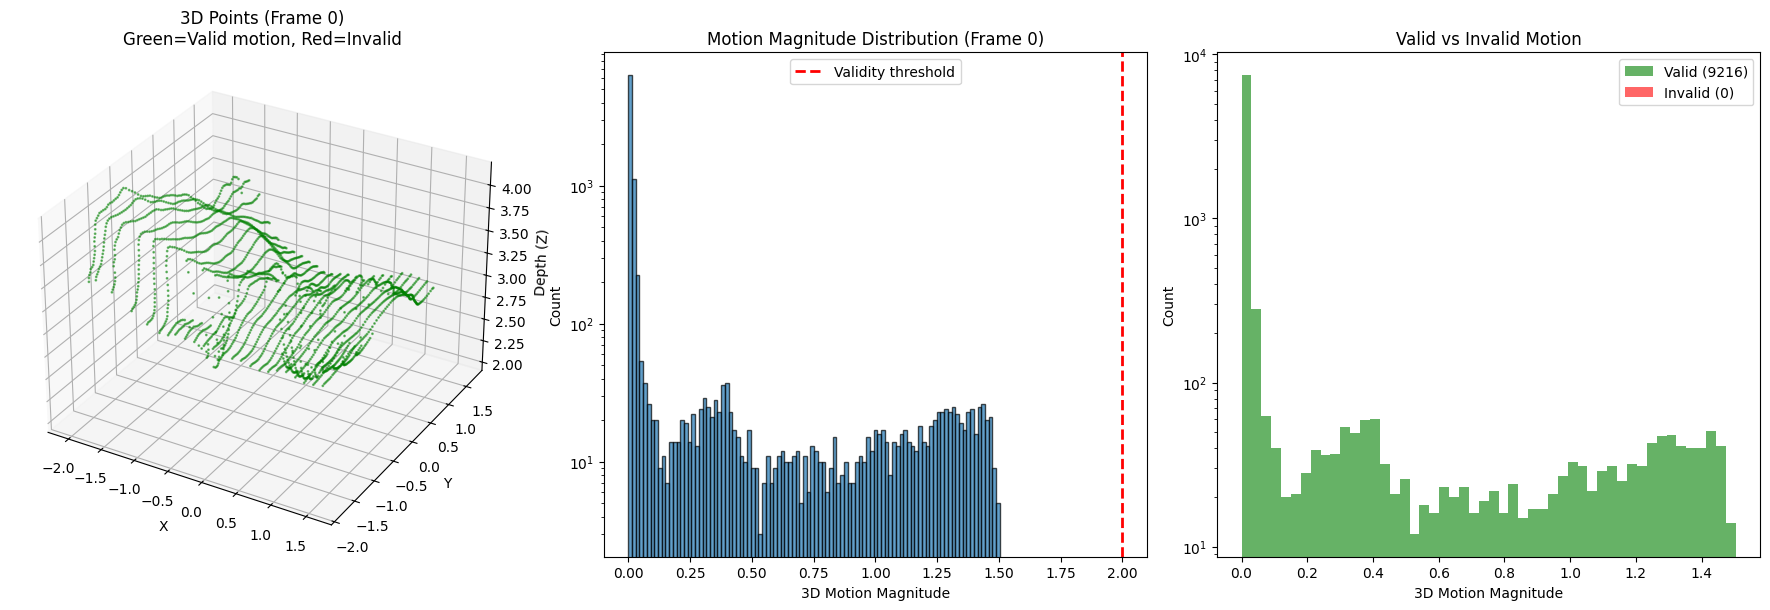

In [8]:
# ========================================
# STEP 2: Compute 3D Points and Motion
# ========================================
print(f"\n=== STEP 2: Computing 3D points and motion vectors ===")

points_3d, motion_3d, motion_valid_mask = compute_3d_points_and_motion(
    depth, flow, downsample_factor=8, max_motion_magnitude=2.0
)

print(f"✓ 3D points shape: {points_3d.shape}")
print(f"✓ 3D motion shape: {motion_3d.shape}")
print(f"✓ Motion validity mask shape: {motion_valid_mask.shape}")
print(f"✓ Valid points in first frame: {np.sum(motion_valid_mask[0])}/{len(motion_valid_mask[0])}")

# Visualize 3D points from first frame
fig = plt.figure(figsize=(18, 6))

# 3D scatter plot
ax1 = fig.add_subplot(131, projection='3d')
stride = max(1, len(points_3d[0]) // 2000)
pts = points_3d[0][::stride]
valid = motion_valid_mask[0][::stride]
colors = ['green' if v else 'red' for v in valid]
ax1.scatter(pts[:, 0], pts[:, 1], pts[:, 2], c=colors, s=1, alpha=0.5)
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Depth (Z)')
ax1.set_title(f'3D Points (Frame 0)\nGreen=Valid motion, Red=Invalid')

# Motion magnitude histogram
ax2 = fig.add_subplot(132)
motion_mag = np.linalg.norm(motion_3d[0], axis=-1)
ax2.hist(motion_mag, bins=100, alpha=0.7, edgecolor='black')
ax2.axvline(2.0, color='red', linestyle='--', linewidth=2, label='Validity threshold')
ax2.set_xlabel('3D Motion Magnitude')
ax2.set_ylabel('Count')
ax2.set_title(f'Motion Magnitude Distribution (Frame 0)')
ax2.legend()
ax2.set_yscale('log')

# Valid vs invalid motion comparison
ax3 = fig.add_subplot(133)
valid_motion = motion_mag[motion_valid_mask[0]]
invalid_motion = motion_mag[~motion_valid_mask[0]]
ax3.hist(valid_motion, bins=50, alpha=0.6, label=f'Valid ({len(valid_motion)})', color='green')
ax3.hist(invalid_motion, bins=50, alpha=0.6, label=f'Invalid ({len(invalid_motion)})', color='red')
ax3.set_xlabel('3D Motion Magnitude')
ax3.set_ylabel('Count')
ax3.set_title('Valid vs Invalid Motion')
ax3.legend()
ax3.set_yscale('log')

plt.tight_layout()
plt.show()


=== STEP 3: Extracting gestalt segmentation ===


✓ Squared depth shape: (90, 96, 96)
✓ Squared flow shape: (89, 96, 96, 2)
Debug: flow_magnitude shape: 9216, depth_flat shape: 9216, points shape: 9216
Segmentation extracted: 1843/9216 points (20.0%) in ROI
✓ Segmentation mask: 1843/9216 points in ROI
✓ Combined mask: 1843/9216 points pass both filters


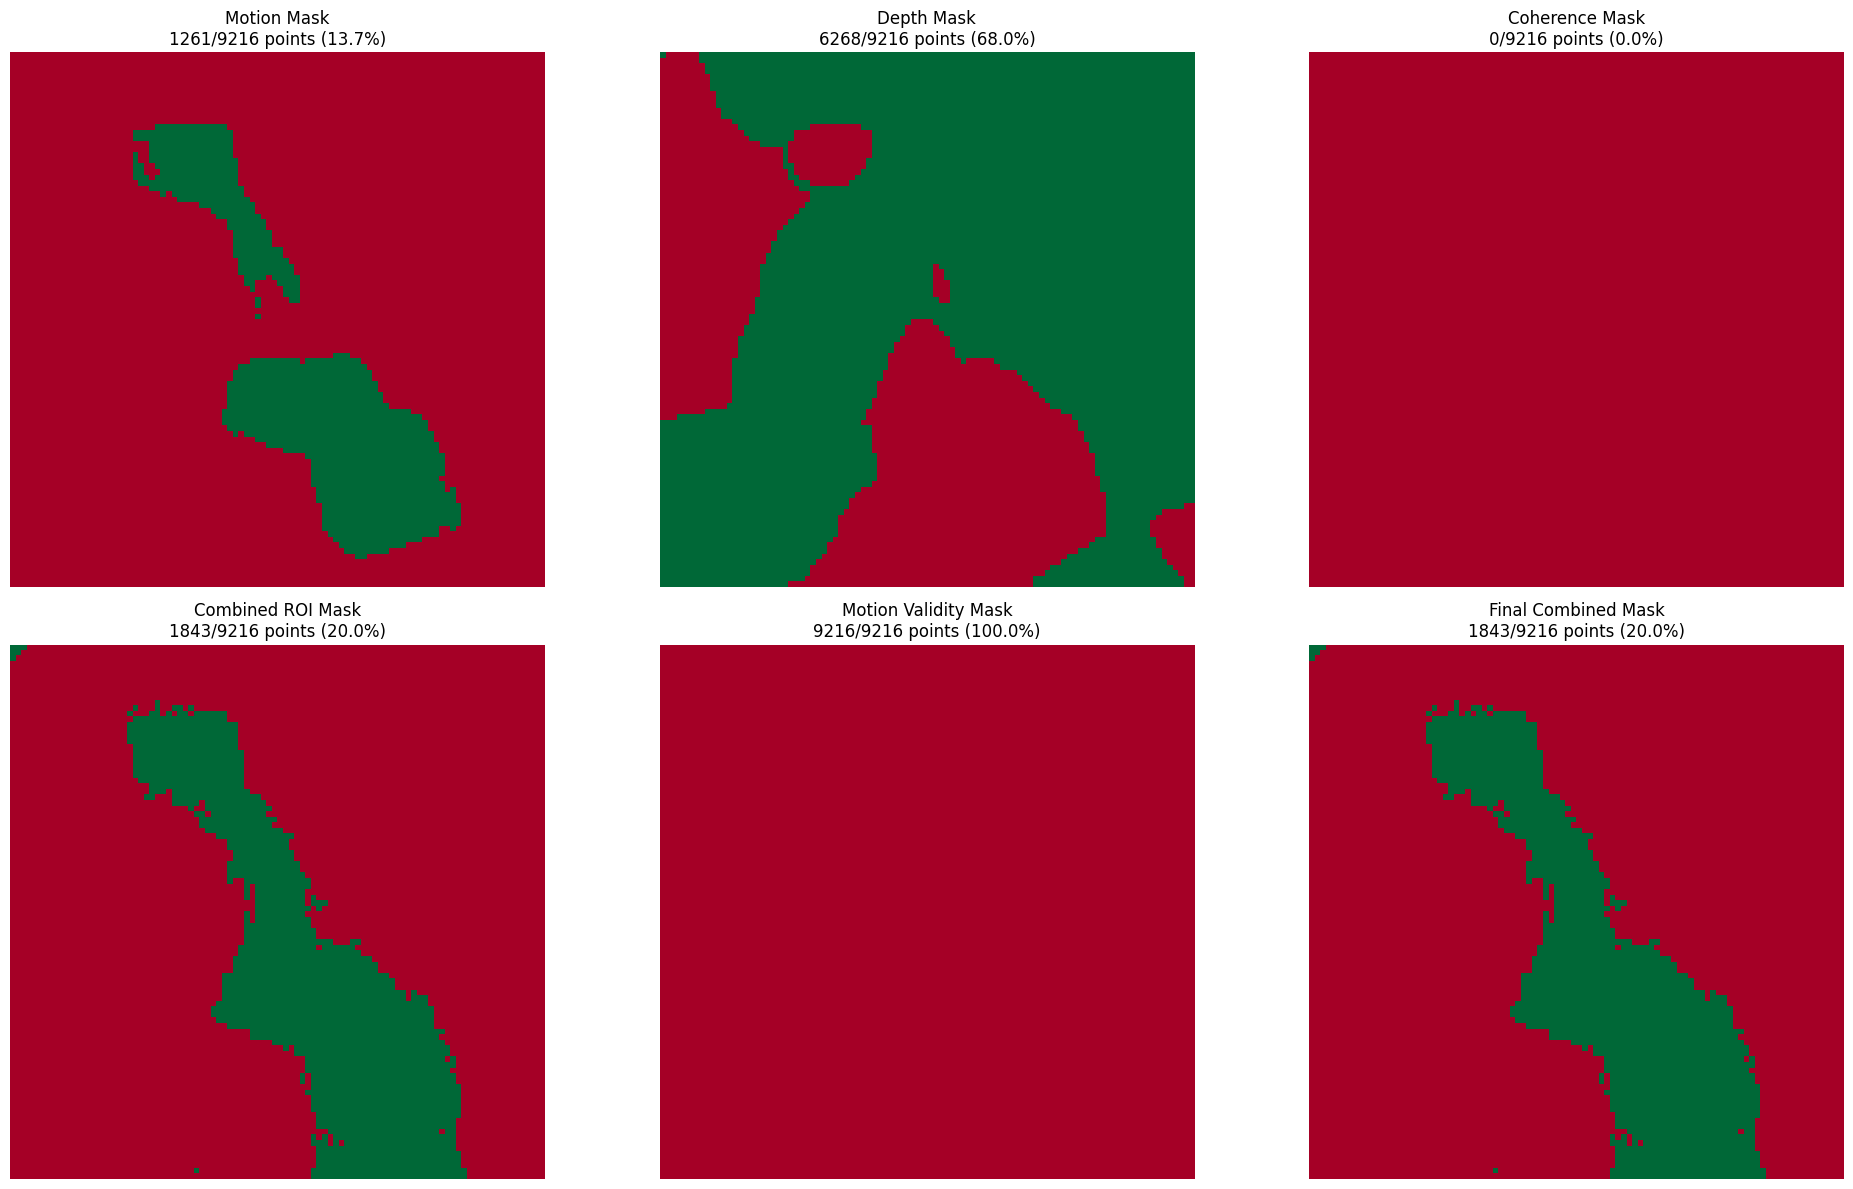

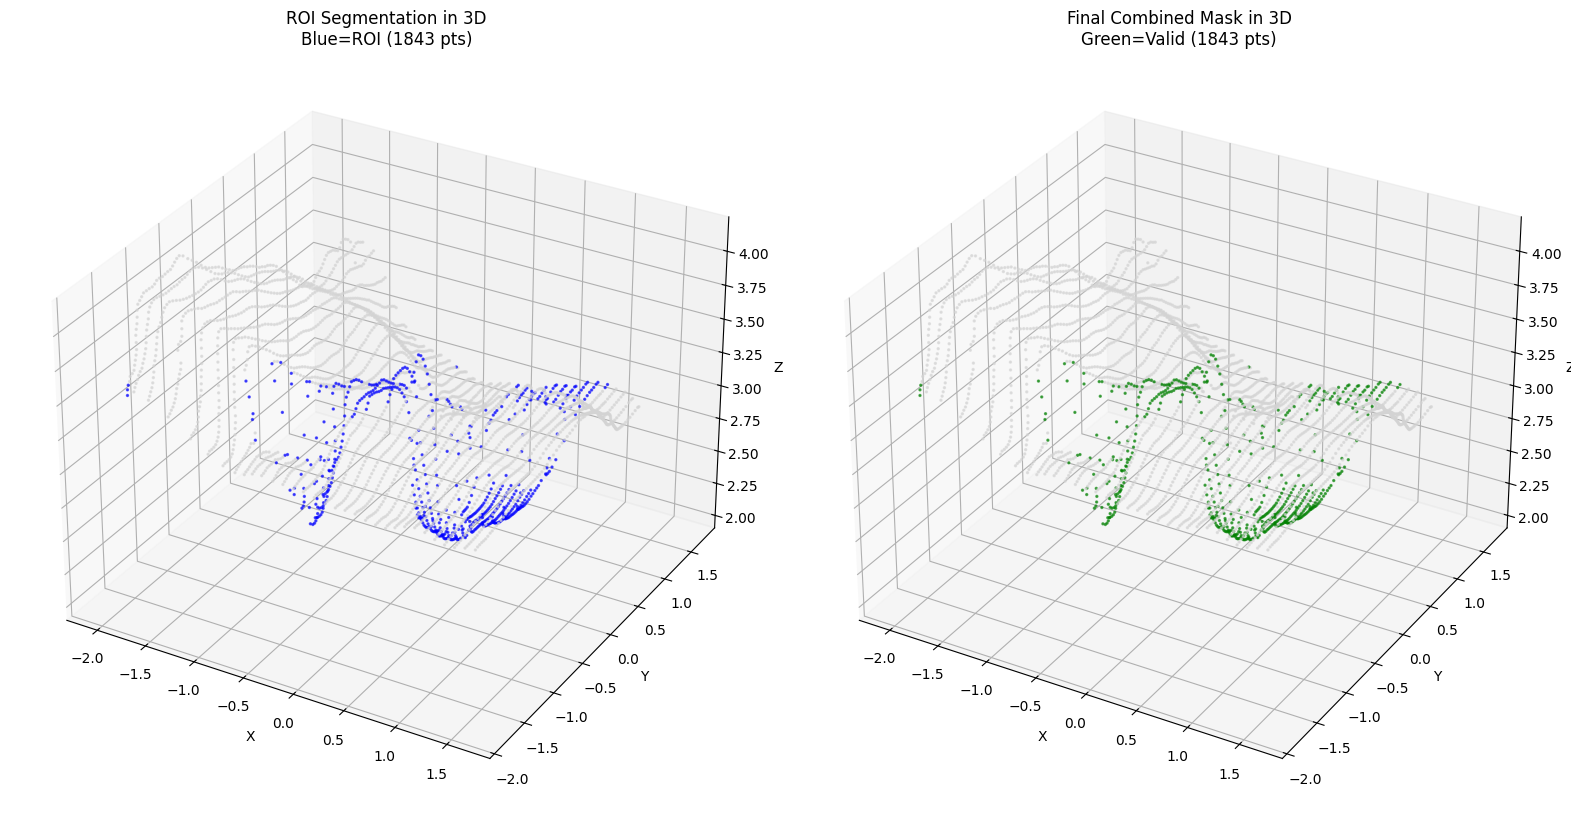

In [9]:
# ========================================
# STEP 3: Extract Gestalt Segmentation (WITH VISUALIZATION!)
# ========================================
print(f"\n=== STEP 3: Extracting gestalt segmentation ===")

# Prepare squared data (matching compute_3d_points_and_motion)
orig_H, orig_W = depth.shape[1:3]
target_hw = max(orig_H, orig_W) // 8
target_hw = (target_hw // 32) * 32
if target_hw < 32:
    target_hw = 32

depth_sq = resize_to_square(depth, target_hw)
flow_sq = resize_to_square(flow, target_hw)

print(f"✓ Squared depth shape: {depth_sq.shape}")
print(f"✓ Squared flow shape: {flow_sq.shape}")

# Extract segmentation mask
first_frame_seg = extract_gestalt_segmentation(depth_sq, flow_sq, points_3d)
print(f"✓ Segmentation mask: {np.sum(first_frame_seg)}/{len(first_frame_seg)} points in ROI")

# Combine with motion validity mask
combined_mask = first_frame_seg & motion_valid_mask[0]
print(f"✓ Combined mask: {np.sum(combined_mask)}/{len(combined_mask)} points pass both filters")

# VISUALIZATION: Show segmentation components
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# Compute segmentation components for visualization
first_depth = depth_sq[0]
first_flow = flow_sq[0]
flow_magnitude = np.linalg.norm(first_flow, axis=-1).flatten()
depth_flat = first_depth.flatten()

# Heuristic 1: Motion mask
flow_threshold = np.median(flow_magnitude) + 0.5 * np.std(flow_magnitude)
motion_mask = flow_magnitude > flow_threshold

# Heuristic 2: Depth mask
depth_median = np.median(depth_flat)
depth_std = np.std(depth_flat)
depth_min_thresh = depth_median - 0.8 * depth_std
depth_max_thresh = depth_median + 0.8 * depth_std
depth_mask = (depth_flat > depth_min_thresh) & (depth_flat < depth_max_thresh)

# Heuristic 3: Coherence mask
from scipy.ndimage import uniform_filter
kernel_size = 5
flow_x = first_flow[..., 0]
flow_y = first_flow[..., 1]
flow_x_var = uniform_filter(flow_x**2, kernel_size) - uniform_filter(flow_x, kernel_size)**2
flow_y_var = uniform_filter(flow_y**2, kernel_size) - uniform_filter(flow_y, kernel_size)**2
flow_coherence = 1.0 / (1.0 + flow_x_var + flow_y_var)
coherence_threshold = np.median(flow_coherence.flatten()) + 0.3 * np.std(flow_coherence.flatten())
coherence_mask = flow_coherence.flatten() > coherence_threshold

# Plot each component
hw = int(np.sqrt(len(first_frame_seg)))

axes[0, 0].imshow(motion_mask.reshape(hw, hw), cmap='RdYlGn')
axes[0, 0].set_title(f'Motion Mask\n{np.sum(motion_mask)}/{len(motion_mask)} points ({100*np.sum(motion_mask)/len(motion_mask):.1f}%)')
axes[0, 0].axis('off')

axes[0, 1].imshow(depth_mask.reshape(hw, hw), cmap='RdYlGn')
axes[0, 1].set_title(f'Depth Mask\n{np.sum(depth_mask)}/{len(depth_mask)} points ({100*np.sum(depth_mask)/len(depth_mask):.1f}%)')
axes[0, 1].axis('off')

axes[0, 2].imshow(coherence_mask.reshape(hw, hw), cmap='RdYlGn')
axes[0, 2].set_title(f'Coherence Mask\n{np.sum(coherence_mask)}/{len(coherence_mask)} points ({100*np.sum(coherence_mask)/len(coherence_mask):.1f}%)')
axes[0, 2].axis('off')

axes[1, 0].imshow(first_frame_seg.reshape(hw, hw), cmap='RdYlGn')
axes[1, 0].set_title(f'Combined ROI Mask\n{np.sum(first_frame_seg)}/{len(first_frame_seg)} points ({100*np.sum(first_frame_seg)/len(first_frame_seg):.1f}%)')
axes[1, 0].axis('off')

axes[1, 1].imshow(motion_valid_mask[0].reshape(hw, hw), cmap='RdYlGn')
axes[1, 1].set_title(f'Motion Validity Mask\n{np.sum(motion_valid_mask[0])}/{len(motion_valid_mask[0])} points ({100*np.sum(motion_valid_mask[0])/len(motion_valid_mask[0]):.1f}%)')
axes[1, 1].axis('off')

axes[1, 2].imshow(combined_mask.reshape(hw, hw), cmap='RdYlGn')
axes[1, 2].set_title(f'Final Combined Mask\n{np.sum(combined_mask)}/{len(combined_mask)} points ({100*np.sum(combined_mask)/len(combined_mask):.1f}%)')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

# 3D visualization of segmented points
fig = plt.figure(figsize=(16, 8))

ax1 = fig.add_subplot(121, projection='3d')
stride = max(1, len(points_3d[0]) // 3000)
pts = points_3d[0][::stride]
seg_mask = first_frame_seg[::stride]
colors = ['blue' if s else 'lightgray' for s in seg_mask]
ax1.scatter(pts[:, 0], pts[:, 1], pts[:, 2], c=colors, s=2, alpha=0.6)
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')
ax1.set_title(f'ROI Segmentation in 3D\nBlue=ROI ({np.sum(first_frame_seg)} pts)')

ax2 = fig.add_subplot(122, projection='3d')
final_colors = ['green' if c else 'lightgray' for c in combined_mask[::stride]]
ax2.scatter(pts[:, 0], pts[:, 1], pts[:, 2], c=final_colors, s=2, alpha=0.6)
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('Z')
ax2.set_title(f'Final Combined Mask in 3D\nGreen=Valid ({np.sum(combined_mask)} pts)')

plt.tight_layout()
plt.show()


=== STEP 4: Creating hierarchical k-means clustering ===
Creating clustering with 50 blobs and 5 hyperblobs...
✓ K-means clustering created
✓ ROI blob indices: 9 blobs
✓ ROI hyperblob indices: 1 hyperblobs
✓ Total points: 9216


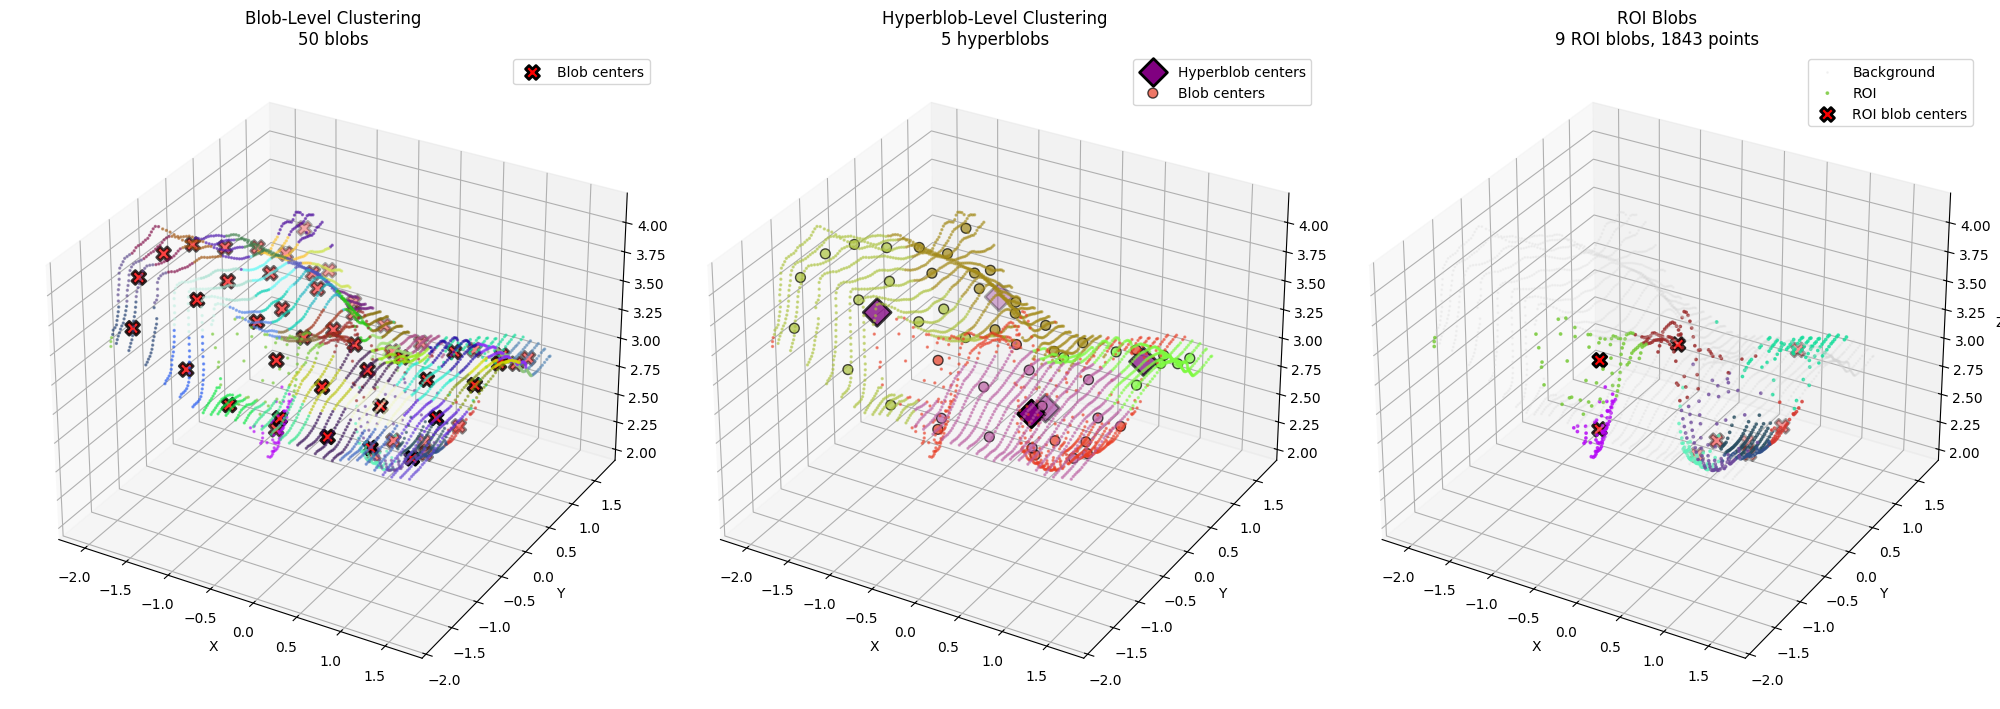

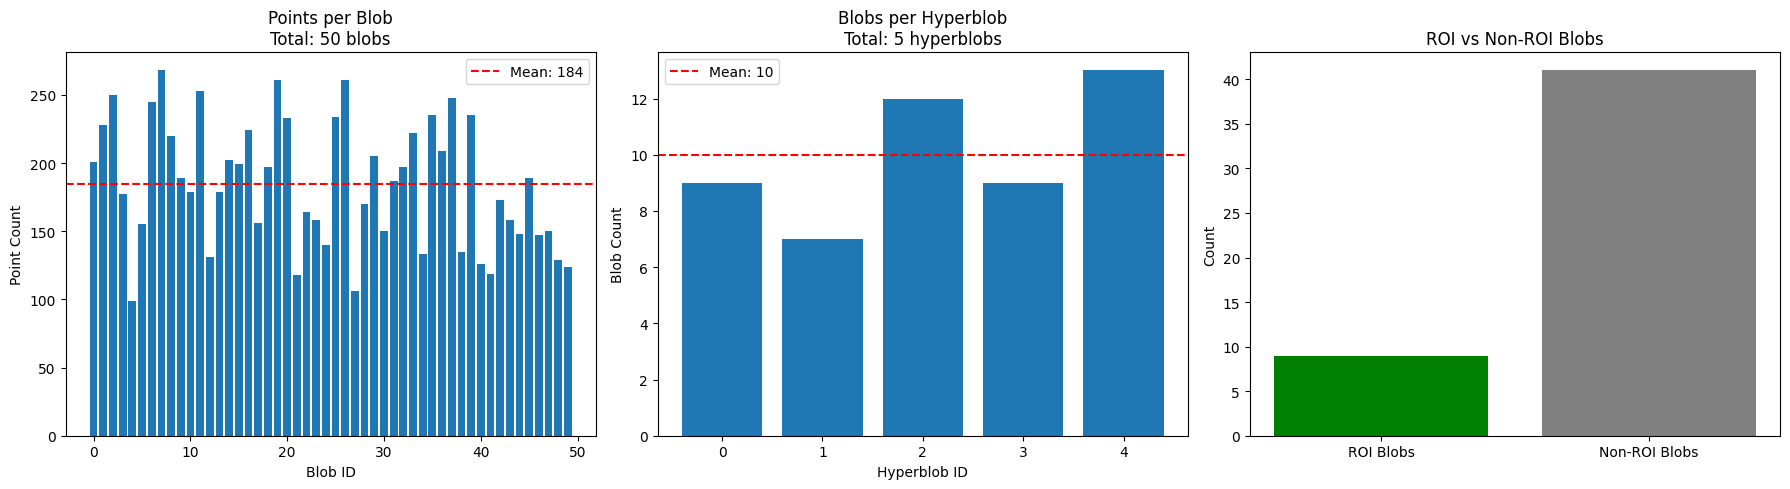

In [10]:
# ========================================
# STEP 4: Hierarchical K-Means Clustering
# ========================================
print(f"\n=== STEP 4: Creating hierarchical k-means clustering ===")

number_of_blobs = custom_hyperparams["number_of_blobs"]
number_of_hyperblobs = custom_hyperparams["number_of_hyperblobs"]

tracked_points = points_3d
tracked_motion_vectors = motion_3d

print(f"Creating clustering with {number_of_blobs} blobs and {number_of_hyperblobs} hyperblobs...")

kmeans_chm, roi_blob_indices, roi_hyperblob_indices = make_hierarchical_kmeans_chm_with_mask_fixed_hyperblob(
    tracked_points, number_of_blobs, number_of_hyperblobs,
    segmentation_mask=combined_mask, motion_vectors=tracked_motion_vectors
)

print(f"✓ K-means clustering created")
print(f"✓ ROI blob indices: {len(roi_blob_indices)} blobs")
print(f"✓ ROI hyperblob indices: {len(roi_hyperblob_indices)} hyperblobs")
print(f"✓ Total points: {kmeans_chm['datapoints', 'datapoint_positions'].shape[0]}")

# Visualize clustering
blob_assignments = np.array(kmeans_chm['datapoints', 'blob_assignments'])
hyperblob_assignments = np.array(kmeans_chm['blobs', 'hyperblob_assignments'])
blob_means = np.array(kmeans_chm['blobs', 'blob_means'])
hyperblob_means = np.array(kmeans_chm['hyperblobs', 'hyperblob_means'])

fig = plt.figure(figsize=(20, 8))

# Blob-level clustering
ax1 = fig.add_subplot(131, projection='3d')
stride = max(1, len(points_3d[0]) // 3000)
pts = points_3d[0][::stride]
assignments = blob_assignments[::stride]

# Create color map for blobs
np.random.seed(42)
blob_colors = np.random.rand(number_of_blobs, 3)
point_colors = blob_colors[assignments]

ax1.scatter(pts[:, 0], pts[:, 1], pts[:, 2], c=point_colors, s=2, alpha=0.5)
ax1.scatter(blob_means[:, 0], blob_means[:, 1], blob_means[:, 2], 
           c='red', s=100, marker='X', edgecolors='black', linewidths=2, label='Blob centers')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')
ax1.set_title(f'Blob-Level Clustering\n{number_of_blobs} blobs')
ax1.legend()

# Hyperblob-level clustering
ax2 = fig.add_subplot(132, projection='3d')
hyperblob_colors = np.random.rand(number_of_hyperblobs, 3)
blob_hyperblob_colors = hyperblob_colors[hyperblob_assignments]
point_hyperblob_colors = blob_hyperblob_colors[assignments]

ax2.scatter(pts[:, 0], pts[:, 1], pts[:, 2], c=point_hyperblob_colors, s=2, alpha=0.5)
ax2.scatter(hyperblob_means[:, 0], hyperblob_means[:, 1], hyperblob_means[:, 2],
           c='purple', s=200, marker='D', edgecolors='black', linewidths=2, label='Hyperblob centers')
ax2.scatter(blob_means[:, 0], blob_means[:, 1], blob_means[:, 2],
           c=blob_hyperblob_colors, s=50, marker='o', edgecolors='black', linewidths=1, alpha=0.7, label='Blob centers')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('Z')
ax2.set_title(f'Hyperblob-Level Clustering\n{number_of_hyperblobs} hyperblobs')
ax2.legend()

# ROI visualization
ax3 = fig.add_subplot(133, projection='3d')
roi_mask = combined_mask[::stride]
roi_pts = pts[roi_mask]
roi_assignments = assignments[roi_mask]
roi_point_colors = blob_colors[roi_assignments]

ax3.scatter(pts[~roi_mask][:, 0], pts[~roi_mask][:, 1], pts[~roi_mask][:, 2], 
           c='lightgray', s=1, alpha=0.2, label='Background')
ax3.scatter(roi_pts[:, 0], roi_pts[:, 1], roi_pts[:, 2], 
           c=roi_point_colors, s=3, alpha=0.7, label='ROI')
ax3.scatter(blob_means[roi_blob_indices][:, 0], blob_means[roi_blob_indices][:, 1], blob_means[roi_blob_indices][:, 2],
           c='red', s=100, marker='X', edgecolors='black', linewidths=2, label='ROI blob centers')
ax3.set_xlabel('X')
ax3.set_ylabel('Y')
ax3.set_zlabel('Z')
ax3.set_title(f'ROI Blobs\n{len(roi_blob_indices)} ROI blobs, {np.sum(combined_mask)} points')
ax3.legend()

plt.tight_layout()
plt.show()

# Distribution statistics
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Points per blob
unique_blobs, counts = np.unique(blob_assignments, return_counts=True)
axes[0].bar(range(len(unique_blobs)), counts)
axes[0].axhline(np.mean(counts), color='red', linestyle='--', label=f'Mean: {np.mean(counts):.0f}')
axes[0].set_xlabel('Blob ID')
axes[0].set_ylabel('Point Count')
axes[0].set_title(f'Points per Blob\nTotal: {number_of_blobs} blobs')
axes[0].legend()

# Blobs per hyperblob
unique_hyperblobs, hcounts = np.unique(hyperblob_assignments, return_counts=True)
axes[1].bar(range(len(unique_hyperblobs)), hcounts)
axes[1].axhline(np.mean(hcounts), color='red', linestyle='--', label=f'Mean: {np.mean(hcounts):.0f}')
axes[1].set_xlabel('Hyperblob ID')
axes[1].set_ylabel('Blob Count')
axes[1].set_title(f'Blobs per Hyperblob\nTotal: {number_of_hyperblobs} hyperblobs')
axes[1].legend()

# ROI vs non-ROI distribution
roi_blob_mask = np.isin(np.arange(number_of_blobs), roi_blob_indices)
axes[2].bar(['ROI Blobs', 'Non-ROI Blobs'], 
           [len(roi_blob_indices), number_of_blobs - len(roi_blob_indices)],
           color=['green', 'gray'])
axes[2].set_ylabel('Count')
axes[2].set_title(f'ROI vs Non-ROI Blobs')

plt.tight_layout()
plt.show()

In [11]:
# hierarchical k-means to crudely estimate the prior given a scene. 



=== STEP 5: Setting up HDGMM model ===


✓ Empirical statistics computed:
  - Hyperblob mean (mu_H): [-0.01071103 -0.01562153  3.2578144 ]
  - Hyperblob scale (sigma_H): 25.00
  - Mean blobs per hyperblob: 9.0
  - Mean points per blob: 204.8
✓ Hyperparameters created
✓ Gibbs sampling configuration:
  Active parameters: blob_weights, blob_assignments, hyperblob_assignments, blob_covs, blob_vel_covs, blob_vel_means, hyperblob_means, blob_means


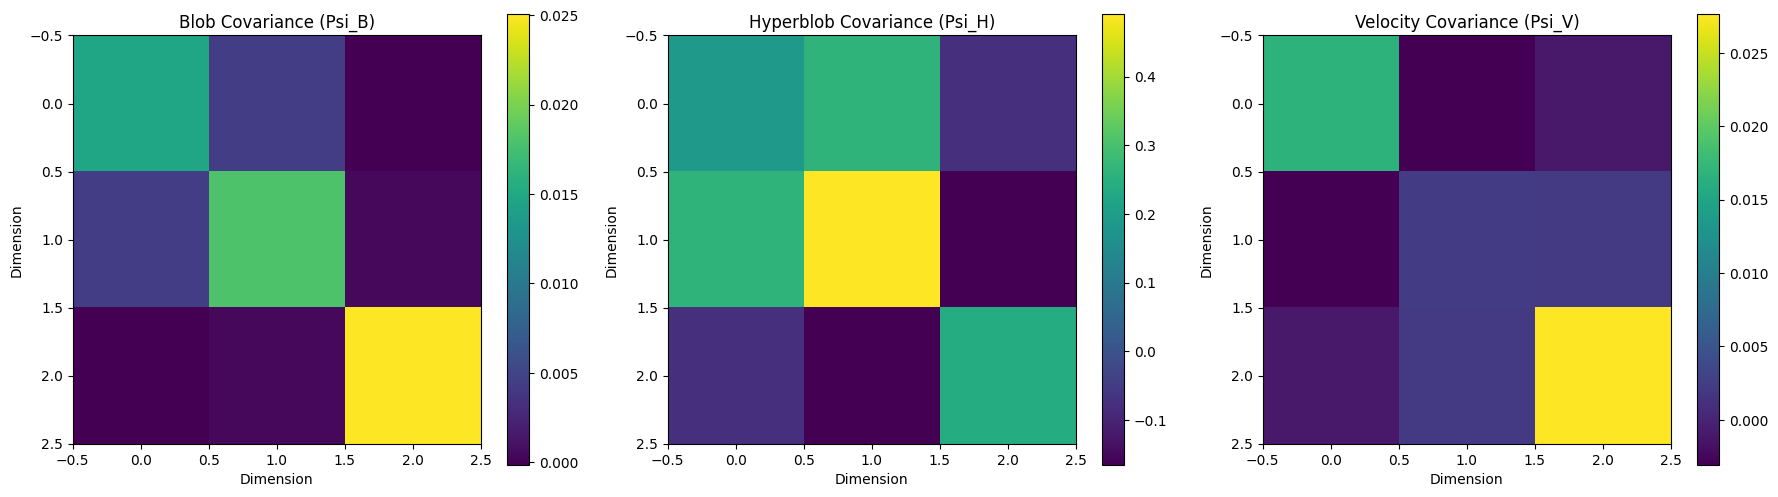

In [12]:
# ========================================
# STEP 5: Initialize HDGMM Model and Hyperparameters
# ========================================
print(f"\n=== STEP 5: Setting up HDGMM model ===")

# Extract statistics from clustering
num_datapoints = kmeans_chm['datapoints', 'datapoint_positions'].shape[0]
num_blobs = kmeans_chm['blobs', 'hyperblob_assignments'].shape[0]
num_hyperblobs = kmeans_chm['hyperblobs', 'hyperblob_means'].shape[0]

empirical_mu_H = jnp.median(kmeans_chm['datapoints', 'datapoint_positions'], axis=0)
empirical_sigma_H = (10*0.5)**2
empirical_Psi_B = jnp.median(kmeans_chm['blobs', 'blob_covs'][roi_blob_indices], axis=0)
empirical_Psi_H = jnp.median(kmeans_chm['hyperblobs', 'hyperblob_covs'][roi_hyperblob_indices], axis=0)
empirical_Psi_V = jnp.median(kmeans_chm['blobs', 'blob_vel_covs'][roi_blob_indices], axis=0)

mean_blobs_per_roi_hyperblob = jnp.sum(jnp.isin(kmeans_chm['blobs', 'hyperblob_assignments'], roi_hyperblob_indices)) / len(roi_hyperblob_indices)
empirical_nu_H = f_(int(mean_blobs_per_roi_hyperblob))

mean_points_per_roi_blob = jnp.sum(jnp.isin(kmeans_chm['datapoints', 'blob_assignments'], roi_blob_indices)) / len(roi_blob_indices)
empirical_nu_B = empirical_nu_V = f_(int(mean_points_per_roi_blob))

print(f"✓ Empirical statistics computed:")
print(f"  - Hyperblob mean (mu_H): {empirical_mu_H}")
print(f"  - Hyperblob scale (sigma_H): {empirical_sigma_H:.2f}")
print(f"  - Mean blobs per hyperblob: {mean_blobs_per_roi_hyperblob:.1f}")
print(f"  - Mean points per blob: {mean_points_per_roi_blob:.1f}")

# Create hyperparameters
hypers = HDGMM_Hyperparams.create(
    outlier_prob=f_(0.001),
    outlier_velocity_gamma_shape=f_(7.5),
    outlier_velocity_gamma_rate=f_(0.5),
    alpha=f_(1.0),
    beta=f_(1.0),
    mu_H=empirical_mu_H,
    sigma_H=empirical_sigma_H,
    nu_H=empirical_nu_H,
    Psi_H=empirical_Psi_H,
    nu_B=empirical_nu_B,
    Psi_B=empirical_Psi_B,
    sigma_V=f_(10e14),
    nu_V=empirical_nu_V,
    Psi_V=empirical_Psi_V,
    translation_gaussian_scale=snp(f_(0.2)),
    translation_max_radius=snp(0.35),
    translation_num_radii_cells=snp(15),
    translation_theta_step_deg=snp(15),
    rotation_vmf_kappa=snp(f_(100)),
    rotation_angle_max_deg=snp(25),
    rotation_angle_step_deg=snp(0.375),
    n_hyperblobs=num_hyperblobs,
    n_blobs=num_blobs,
    n_datapoints=num_datapoints,
)

print(f"✓ Hyperparameters created")

# Set up Gibbs sampling configuration
GIBBS_DIALS = {
    "blob_weights": True,
    "hyperblob_weights": False,
    "blob_assignments": True,
    "hyperblob_assignments": True,
    "hyperblob_covs": False,
    "blob_covs": True,
    "blob_vel_covs": True,
    "blob_vel_means": True,
    "hyperblob_means": True,
    "blob_means": True,
    'hyperblob_rot_vels': False,
    'hyperblob_trans_vels': False
}

print(f"✓ Gibbs sampling configuration:")
active_params = [k for k, v in GIBBS_DIALS.items() if v]
print(f"  Active parameters: {', '.join(active_params)}")

# Visualize hyperparameter-derived covariances
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Blob covariance
im0 = axes[0].imshow(np.array(empirical_Psi_B), cmap='viridis')
axes[0].set_title('Blob Covariance (Psi_B)')
axes[0].set_xlabel('Dimension')
axes[0].set_ylabel('Dimension')
plt.colorbar(im0, ax=axes[0])

# Hyperblob covariance
im1 = axes[1].imshow(np.array(empirical_Psi_H), cmap='viridis')
axes[1].set_title('Hyperblob Covariance (Psi_H)')
axes[1].set_xlabel('Dimension')
axes[1].set_ylabel('Dimension')
plt.colorbar(im1, ax=axes[1])

# Velocity covariance
im2 = axes[2].imshow(np.array(empirical_Psi_V), cmap='viridis')
axes[2].set_title('Velocity Covariance (Psi_V)')
axes[2].set_xlabel('Dimension')
axes[2].set_ylabel('Dimension')
plt.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.show()


=== STEP 6: Running initial Gibbs sampling ===


✓ Model initialized via importance sampling
Running 1001 Gibbs iterations with 5 inner loops...
✓ Gibbs burn-in complete: 1002 samples


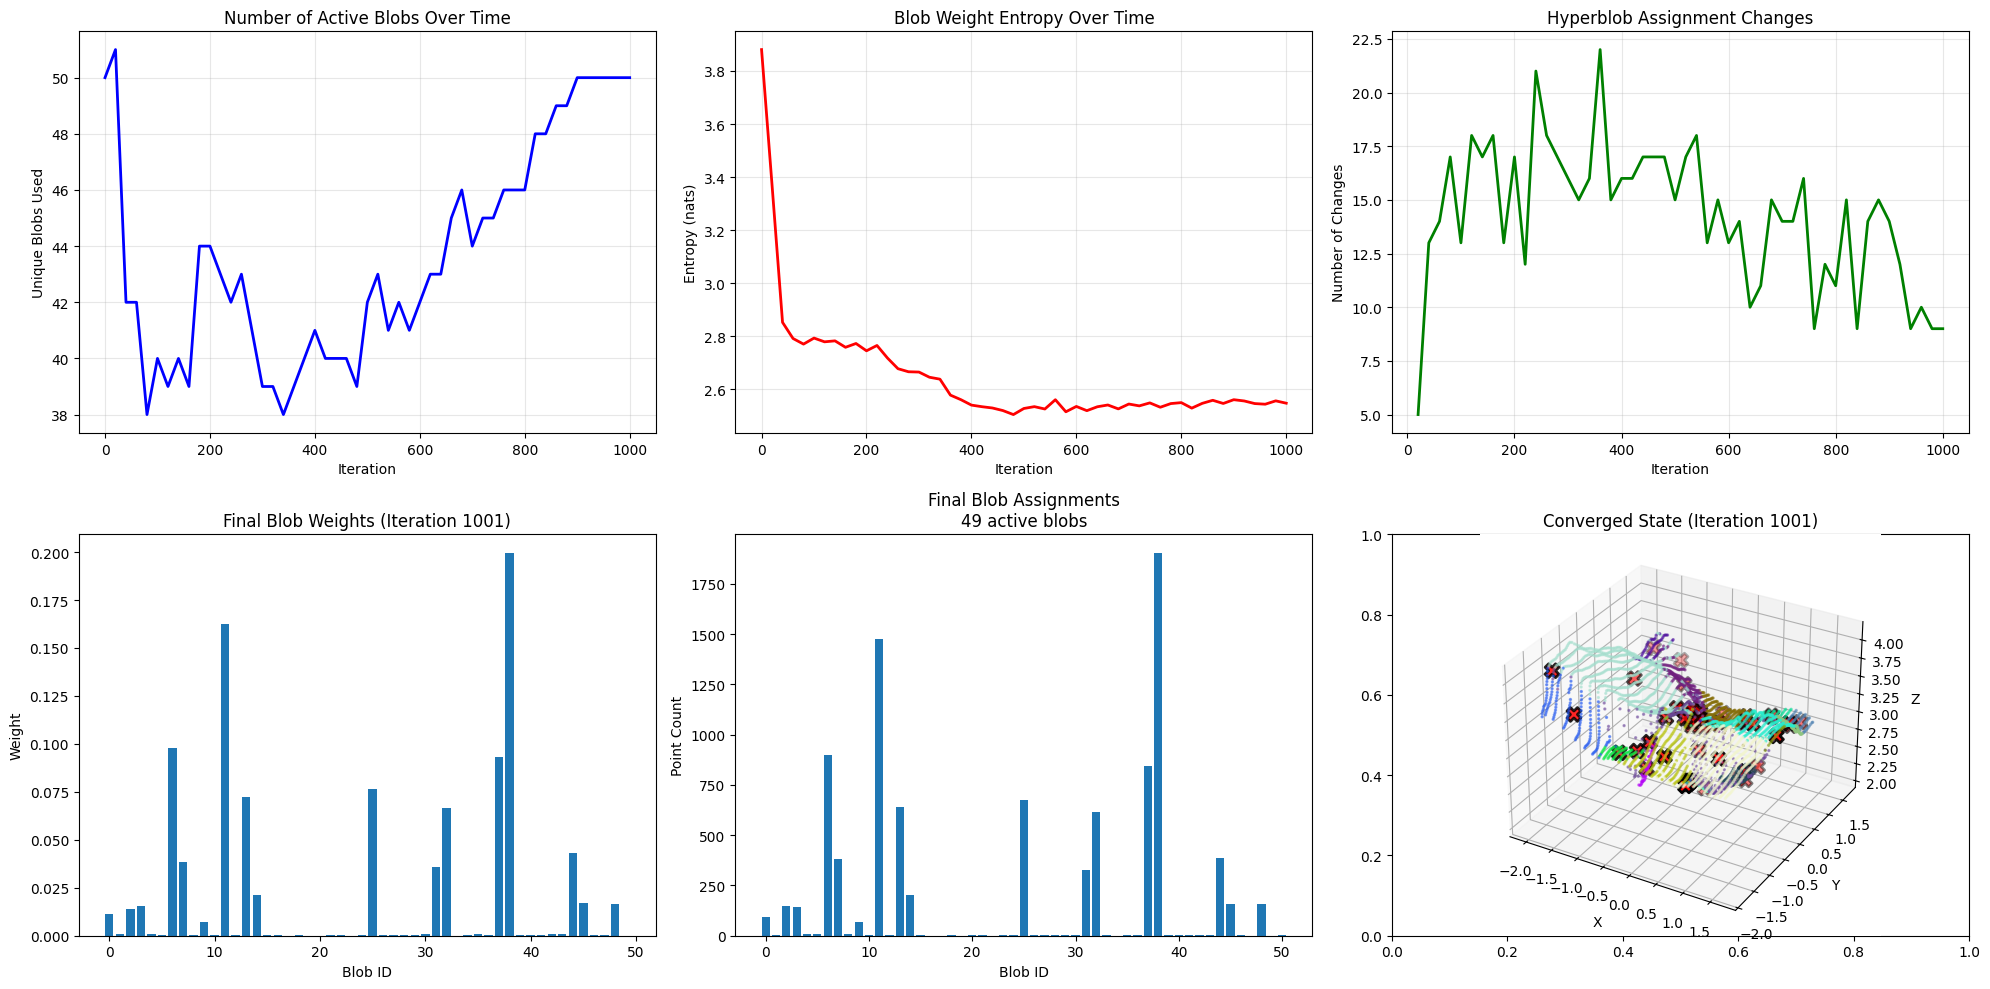


✓ Final converged state statistics:
  - Active blobs: 48/50
  - Outliers: 0 (0.0%)
  - Blob weight entropy: 2.55 nats
  - Mean points per active blob: 90.4


In [13]:
# ========================================
# STEP 6: Initial Gibbs Sampling (Burn-in)
# ========================================
print(f"\n=== STEP 6: Running initial Gibbs sampling ===")

key = jkey(np.random.randint(1e9))

# Initialize model with importance sampling
key, key_importance = jax.random.split(key)
init_tr, _ = model_jimportance(key_importance, kmeans_chm, (hypers,))
init_hdgmm_state = init_tr.get_retval()

print(f"✓ Model initialized via importance sampling")

# Run Gibbs burn-in
num_gibbs_iterations = 1001
num_inner_loops = 5
print(f"Running {num_gibbs_iterations} Gibbs iterations with {num_inner_loops} inner loops...")

key, init_gibbs_key = jax.random.split(key)
gibbs_wtrs = hdgmm_full_gibbs(
    init_gibbs_key, init_hdgmm_state, num_gibbs_iterations, 
    GIBBS_DIALS, use_weighted_blobs=True, num_gibbs_inner_loops=num_inner_loops
)

print(f"✓ Gibbs burn-in complete: {len(gibbs_wtrs)} samples")

# Get final converged state
converged_state = gibbs_wtrs[-1].retval

# Visualize convergence diagnostics
fig, axes = plt.subplots(2, 3, figsize=(20, 10))

# Extract blob assignments over iterations (sample every 10th iteration for speed)
sample_freq = max(1, len(gibbs_wtrs) // 50)
n_blobs_history = []
blob_weight_entropy_history = []
hyperblob_assignment_changes = []

for idx in range(0, len(gibbs_wtrs), sample_freq):
    state = gibbs_wtrs[idx].retval
    blob_assigns = np.array(state.datapoints_state.blob_assignments)
    blob_weights = np.array(state.blobs_state.blob_weights)
    hyperblob_assigns = np.array(state.blobs_state.hyperblob_assignments)
    
    # Track number of unique blobs used
    unique_blobs = len(np.unique(blob_assigns))
    n_blobs_history.append(unique_blobs)
    
    # Track blob weight entropy (higher = more uniform)
    weight_probs = blob_weights / blob_weights.sum()
    entropy = -np.sum(weight_probs * np.log(weight_probs + 1e-10))
    blob_weight_entropy_history.append(entropy)
    
    if idx > 0:
        prev_hyperblob_assigns = np.array(gibbs_wtrs[idx - sample_freq].retval.blobs_state.hyperblob_assignments)
        n_changes = np.sum(hyperblob_assigns != prev_hyperblob_assigns)
        hyperblob_assignment_changes.append(n_changes)

# Plot convergence metrics
iterations = np.arange(0, len(gibbs_wtrs), sample_freq)

axes[0, 0].plot(iterations, n_blobs_history, 'b-', linewidth=2)
axes[0, 0].set_xlabel('Iteration')
axes[0, 0].set_ylabel('Unique Blobs Used')
axes[0, 0].set_title('Number of Active Blobs Over Time')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(iterations, blob_weight_entropy_history, 'r-', linewidth=2)
axes[0, 1].set_xlabel('Iteration')
axes[0, 1].set_ylabel('Entropy (nats)')
axes[0, 1].set_title('Blob Weight Entropy Over Time')
axes[0, 1].grid(True, alpha=0.3)

axes[0, 2].plot(iterations[1:], hyperblob_assignment_changes, 'g-', linewidth=2)
axes[0, 2].set_xlabel('Iteration')
axes[0, 2].set_ylabel('Number of Changes')
axes[0, 2].set_title('Hyperblob Assignment Changes')
axes[0, 2].grid(True, alpha=0.3)

# Final state visualizations
final_blob_assigns = np.array(converged_state.datapoints_state.blob_assignments)
final_blob_weights = np.array(converged_state.blobs_state.blob_weights)
final_blob_means = np.array(converged_state.blobs_state.blob_means)

axes[1, 0].bar(range(len(final_blob_weights)), final_blob_weights)
axes[1, 0].set_xlabel('Blob ID')
axes[1, 0].set_ylabel('Weight')
axes[1, 0].set_title(f'Final Blob Weights (Iteration {num_gibbs_iterations})')

# Blob assignment distribution
unique_assigns, assign_counts = np.unique(final_blob_assigns, return_counts=True)
axes[1, 1].bar(unique_assigns, assign_counts)
axes[1, 1].set_xlabel('Blob ID')
axes[1, 1].set_ylabel('Point Count')
axes[1, 1].set_title(f'Final Blob Assignments\n{len(unique_assigns)} active blobs')

# 3D visualization of converged state
ax_3d = fig.add_subplot(2, 3, 6, projection='3d')
stride = max(1, len(points_3d[0]) // 3000)
pts = points_3d[0][::stride]
assigns = final_blob_assigns[::stride]

# Separate outliers from inliers
outlier_mask = assigns == num_blobs  # Outliers have blob_id == n_blobs
inlier_pts = pts[~outlier_mask]
inlier_assigns = assigns[~outlier_mask]
outlier_pts = pts[outlier_mask]

# Plot inliers with colors
if len(inlier_pts) > 0:
    np.random.seed(42)
    blob_colors = np.random.rand(num_blobs, 3)
    point_colors = blob_colors[inlier_assigns]
    ax_3d.scatter(inlier_pts[:, 0], inlier_pts[:, 1], inlier_pts[:, 2], c=point_colors, s=2, alpha=0.5)

# Plot outliers in black
if len(outlier_pts) > 0:
    ax_3d.scatter(outlier_pts[:, 0], outlier_pts[:, 1], outlier_pts[:, 2], 
                 c='black', s=3, alpha=0.8, marker='x', label='Outliers')

# Plot blob centers
ax_3d.scatter(final_blob_means[:, 0], final_blob_means[:, 1], final_blob_means[:, 2],
             c='red', s=100, marker='X', edgecolors='black', linewidths=2, label='Blob centers')
ax_3d.set_xlabel('X')
ax_3d.set_ylabel('Y')
ax_3d.set_zlabel('Z')
ax_3d.set_title(f'Converged State (Iteration {num_gibbs_iterations})')
if len(outlier_pts) > 0:
    ax_3d.legend()

plt.tight_layout()
plt.show()

print(f"\n✓ Final converged state statistics:")
print(f"  - Active blobs: {len(np.unique(final_blob_assigns[final_blob_assigns < num_blobs]))}/{num_blobs}")
print(f"  - Outliers: {np.sum(outlier_mask)} ({100*np.sum(outlier_mask)/len(final_blob_assigns):.1f}%)")
print(f"  - Blob weight entropy: {blob_weight_entropy_history[-1]:.2f} nats")
if len(inlier_assigns) > 0:
    print(f"  - Mean points per active blob: {len(inlier_assigns) / len(np.unique(inlier_assigns)):.1f}")

In [14]:
converged_state

HDGMM_State(
  hypers=HDGMM_Hyperparams(outlier_prob=<jax.Array(0.001, dtype=float32)>, outlier_velocity_gamma_shape=<jax.Array(7.5, dtype=float32)>, outlier_velocity_gamma_rate=<jax.Array(0.5, dtype=float32)>, alpha=<jax.Array(1., dtype=float32)>, beta=<jax.Array(1., dtype=float32)>, mu_H=<jax.Array([-0.01071103, -0.01562153,  3.2578144 ], dtype=float32)>, sigma_H=<jax.Array(25., dtype=float32, weak_type=True)>, nu_H=<jax.Array(9., dtype=float32)>, Psi_H=<jax.Array float32(3, 3) ≈0.11 ±0.22 [≥-0.17, ≤0.49] nonzero:9>, nu_B=<jax.Array(204., dtype=float32)>, Psi_B=<jax.Array float32(3, 3) ≈0.0075 ±0.0089 [≥-0.00014, ≤0.025] nonzero:9>, sigma_V=<jax.Array(1.e+15, dtype=float32)>, nu_V=<jax.Array(204., dtype=float32)>, Psi_V=<jax.Array float32(3, 3) ≈0.0048 ±0.0099 [≥-0.0031, ≤0.028] nonzero:9>, translation_max_radius=StaticJnp(v=<jax.Array(0.35, dtype=float32, weak_type=True)>), translation_num_radii_cells=StaticJnp(v=<jax.Array(15, dtype=int32, weak_type=True)>), translation_theta_step_

In [15]:
# ========================================
# STEP 6.5: COMMENTED OUT - Full Gibbs Sampling on Second Frame
# ========================================
# NOTE: This cell is commented out to use tracking Gibbs instead (see new cell below)

# ========================================
# STEP 6.5: Full Gibbs Sampling on Second Frame
# ========================================
# print(f"\n=== STEP 6.5: Running full Gibbs sampling on second frame ===")

# Prepare second frame data
# second_frame_positions = points_3d[1]  # Shape: (N, 3)
# second_frame_velocities = motion_3d[1]  # Motion from frame 0 to frame 1

# print(f"Second frame positions: {second_frame_positions.shape}")
# print(f"Second frame velocities: {second_frame_velocities.shape}")

# Create updated state with second frame data
# We'll use the converged blob/hyperblob structure from frame 1, but update datapoints
# second_frame_state = HDGMM_State(
#     hypers=converged_state.hypers,
#     hyperblobs_state=converged_state.hyperblobs_state,
#     blobs_state=converged_state.blobs_state,
#     datapoints_state=HDGMM_Datapoints_State(
#         blob_assignments=converged_state.datapoints_state.blob_assignments,  # Start with frame 1 assignments
#         datapoint_positions=jnp.array(second_frame_positions),  # NEW: second frame positions
#         datapoint_vels=jnp.array(second_frame_velocities)  # NEW: second frame velocities
#     )
# )

# print(f"✓ Second frame state initialized from converged first frame state")

# Run full Gibbs sampling on second frame
# num_gibbs_iterations_frame2 = 1000
# num_inner_loops_frame2 = 5
# print(f"Running {num_gibbs_iterations_frame2} Gibbs iterations on second frame...")

# key, gibbs_key_frame2 = jax.random.split(key)
# gibbs_wtrs_frame2 = hdgmm_full_gibbs(
#     gibbs_key_frame2, second_frame_state, num_gibbs_iterations_frame2,
#     GIBBS_DIALS, use_weighted_blobs=True, num_gibbs_inner_loops=num_inner_loops_frame2
# )

# print(f"✓ Second frame Gibbs sampling complete: {len(gibbs_wtrs_frame2)} samples")

# Get final converged state for second frame
# converged_state_frame2 = gibbs_wtrs_frame2[-1].retval

# ========================================
# Visualization: Compare Frame 1 vs Frame 2
# ========================================
# print(f"\n=== Comparing Frame 1 vs Frame 2 ===")

# fig = plt.figure(figsize=(20, 15))

# ---------- CONVERGENCE METRICS ----------
# Extract metrics for both frames
# sample_freq = max(1, len(gibbs_wtrs) // 50)
# n_blobs_history_f1 = []
# blob_weight_entropy_f1 = []
# n_blobs_history_f2 = []
# blob_weight_entropy_f2 = []

# for idx in range(0, len(gibbs_wtrs), sample_freq):
#     state = gibbs_wtrs[idx].retval
#     blob_assigns = np.array(state.datapoints_state.blob_assignments)
#     blob_weights = np.array(state.blobs_state.blob_weights)
    
#     unique_blobs = len(np.unique(blob_assigns))
#     n_blobs_history_f1.append(unique_blobs)
    
#     weight_probs = blob_weights / blob_weights.sum()
#     entropy = -np.sum(weight_probs * np.log(weight_probs + 1e-10))
#     blob_weight_entropy_f1.append(entropy)

# for idx in range(0, len(gibbs_wtrs_frame2), sample_freq):
#     state = gibbs_wtrs_frame2[idx].retval
#     blob_assigns = np.array(state.datapoints_state.blob_assignments)
#     blob_weights = np.array(state.blobs_state.blob_weights)
    
#     unique_blobs = len(np.unique(blob_assigns))
#     n_blobs_history_f2.append(unique_blobs)
    
#     weight_probs = blob_weights / blob_weights.sum()
#     entropy = -np.sum(weight_probs * np.log(weight_probs + 1e-10))
#     blob_weight_entropy_f2.append(entropy)

# Plot convergence comparison
# iterations = np.arange(0, len(gibbs_wtrs), sample_freq)
# iterations_f2 = np.arange(0, len(gibbs_wtrs_frame2), sample_freq)

# ax1 = plt.subplot(3, 3, 1)
# ax1.plot(iterations, n_blobs_history_f1, 'b-', linewidth=2, label='Frame 1', alpha=0.7)
# ax1.plot(iterations_f2, n_blobs_history_f2, 'r-', linewidth=2, label='Frame 2', alpha=0.7)
# ax1.set_xlabel('Iteration')
# ax1.set_ylabel('Unique Blobs Used')
# ax1.set_title('Number of Active Blobs: Frame 1 vs Frame 2')
# ax1.legend()
# ax1.grid(True, alpha=0.3)

# ax2 = plt.subplot(3, 3, 2)
# ax2.plot(iterations, blob_weight_entropy_f1, 'b-', linewidth=2, label='Frame 1', alpha=0.7)
# ax2.plot(iterations_f2, blob_weight_entropy_f2, 'r-', linewidth=2, label='Frame 2', alpha=0.7)
# ax2.set_xlabel('Iteration')
# ax2.set_ylabel('Entropy (nats)')
# ax2.set_title('Blob Weight Entropy: Frame 1 vs Frame 2')
# ax2.legend()
# ax2.grid(True, alpha=0.3)

# ---------- FINAL STATE COMPARISONS ----------
# final_blob_assigns_f1 = np.array(converged_state.datapoints_state.blob_assignments)
# final_blob_weights_f1 = np.array(converged_state.blobs_state.blob_weights)
# final_blob_means_f1 = np.array(converged_state.blobs_state.blob_means)

# final_blob_assigns_f2 = np.array(converged_state_frame2.datapoints_state.blob_assignments)
# final_blob_weights_f2 = np.array(converged_state_frame2.blobs_state.blob_weights)
# final_blob_means_f2 = np.array(converged_state_frame2.blobs_state.blob_means)

# Blob weights comparison
# ax3 = plt.subplot(3, 3, 3)
# x_pos = np.arange(len(final_blob_weights_f1))
# width = 0.35
# ax3.bar(x_pos - width/2, final_blob_weights_f1, width, label='Frame 1', alpha=0.7, color='blue')
# ax3.bar(x_pos + width/2, final_blob_weights_f2, width, label='Frame 2', alpha=0.7, color='red')
# ax3.set_xlabel('Blob ID')
# ax3.set_ylabel('Weight')
# ax3.set_title('Final Blob Weights Comparison')
# ax3.legend()

# Blob assignment distribution
# ax4 = plt.subplot(3, 3, 4)
# unique_assigns_f1, assign_counts_f1 = np.unique(final_blob_assigns_f1, return_counts=True)
# unique_assigns_f2, assign_counts_f2 = np.unique(final_blob_assigns_f2, return_counts=True)
# ax4.bar(unique_assigns_f1 - 0.2, assign_counts_f1, width=0.4, label='Frame 1', alpha=0.7, color='blue')
# ax4.bar(unique_assigns_f2 + 0.2, assign_counts_f2, width=0.4, label='Frame 2', alpha=0.7, color='red')
# ax4.set_xlabel('Blob ID')
# ax4.set_ylabel('Point Count')
# ax4.set_title(f'Final Blob Assignments\nFrame 1: {len(unique_assigns_f1)} blobs, Frame 2: {len(unique_assigns_f2)} blobs')
# ax4.legend()

# Assignment change analysis
# ax5 = plt.subplot(3, 3, 5)
# How many points changed their blob assignment between frames?
# assignment_changes = final_blob_assigns_f1 != final_blob_assigns_f2
# n_changes = np.sum(assignment_changes)
# pct_changes = 100 * n_changes / len(final_blob_assigns_f1)
# ax5.bar(['Same Blob', 'Changed Blob'], 
#         [len(final_blob_assigns_f1) - n_changes, n_changes],
#         color=['green', 'orange'])
# ax5.set_ylabel('Number of Points')
# ax5.set_title(f'Blob Assignment Changes\n{pct_changes:.1f}% changed between frames')
# ax5.text(1, n_changes + 100, f'{n_changes:,} points', ha='center', fontsize=10)

# ---------- 3D VISUALIZATIONS ----------
# Frame 1 converged state
# ax6 = fig.add_subplot(3, 3, 6, projection='3d')
# stride = max(1, len(points_3d[0]) // 3000)
# pts_f1 = points_3d[0][::stride]
# assigns_f1 = final_blob_assigns_f1[::stride]

# outlier_mask_f1 = assigns_f1 == number_of_blobs
# inlier_pts_f1 = pts_f1[~outlier_mask_f1]
# inlier_assigns_f1 = assigns_f1[~outlier_mask_f1]
# outlier_pts_f1 = pts_f1[outlier_mask_f1]

# np.random.seed(42)
# blob_colors = np.random.rand(number_of_blobs, 3)

# if len(inlier_pts_f1) > 0:
#     point_colors_f1 = blob_colors[inlier_assigns_f1]
#     ax6.scatter(inlier_pts_f1[:, 0], inlier_pts_f1[:, 1], inlier_pts_f1[:, 2], 
#                 c=point_colors_f1, s=2, alpha=0.5)
# if len(outlier_pts_f1) > 0:
#     ax6.scatter(outlier_pts_f1[:, 0], outlier_pts_f1[:, 1], outlier_pts_f1[:, 2],
#                 c='black', s=3, alpha=0.8, marker='x', label='Outliers')
# ax6.scatter(final_blob_means_f1[:, 0], final_blob_means_f1[:, 1], final_blob_means_f1[:, 2],
#             c='red', s=100, marker='X', edgecolors='black', linewidths=2, label='Blob centers')
# ax6.set_xlabel('X')
# ax6.set_ylabel('Y')
# ax6.set_zlabel('Z')
# ax6.set_title(f'Frame 1 Converged State\n{len(np.unique(inlier_assigns_f1))} blobs')
# if len(outlier_pts_f1) > 0:
#     ax6.legend()

# Frame 2 converged state
# ax7 = fig.add_subplot(3, 3, 7, projection='3d')
# pts_f2 = points_3d[1][::stride]
# assigns_f2 = final_blob_assigns_f2[::stride]

# outlier_mask_f2 = assigns_f2 == number_of_blobs
# inlier_pts_f2 = pts_f2[~outlier_mask_f2]
# inlier_assigns_f2 = assigns_f2[~outlier_mask_f2]
# outlier_pts_f2 = pts_f2[outlier_mask_f2]

# if len(inlier_pts_f2) > 0:
#     point_colors_f2 = blob_colors[inlier_assigns_f2]
#     ax7.scatter(inlier_pts_f2[:, 0], inlier_pts_f2[:, 1], inlier_pts_f2[:, 2],
#                 c=point_colors_f2, s=2, alpha=0.5)
# if len(outlier_pts_f2) > 0:
#     ax7.scatter(outlier_pts_f2[:, 0], outlier_pts_f2[:, 1], outlier_pts_f2[:, 2],
#                 c='black', s=3, alpha=0.8, marker='x', label='Outliers')
# ax7.scatter(final_blob_means_f2[:, 0], final_blob_means_f2[:, 1], final_blob_means_f2[:, 2],
#             c='red', s=100, marker='X', edgecolors='black', linewidths=2, label='Blob centers')
# ax7.set_xlabel('X')
# ax7.set_ylabel('Y')
# ax7.set_zlabel('Z')
# ax7.set_title(f'Frame 2 Converged State\n{len(np.unique(inlier_assigns_f2))} blobs')
# if len(outlier_pts_f2) > 0:
#     ax7.legend()

# Blob center displacement vectors (frame 1 to frame 2)
# ax8 = fig.add_subplot(3, 3, 8, projection='3d')
# blob_displacement = final_blob_means_f2 - final_blob_means_f1
# ax8.quiver(final_blob_means_f1[:, 0], final_blob_means_f1[:, 1], final_blob_means_f1[:, 2],
#            blob_displacement[:, 0], blob_displacement[:, 1], blob_displacement[:, 2],
#            length=1.0, normalize=False, color='purple', alpha=0.7, arrow_length_ratio=0.3)
# ax8.scatter(final_blob_means_f1[:, 0], final_blob_means_f1[:, 1], final_blob_means_f1[:, 2],
#             c='blue', s=100, marker='o', edgecolors='black', linewidths=2, label='Frame 1 centers', alpha=0.7)
# ax8.scatter(final_blob_means_f2[:, 0], final_blob_means_f2[:, 1], final_blob_means_f2[:, 2],
#             c='red', s=100, marker='s', edgecolors='black', linewidths=2, label='Frame 2 centers', alpha=0.7)
# ax8.set_xlabel('X')
# ax8.set_ylabel('Y')
# ax8.set_zlabel('Z')
# ax8.set_title('Blob Center Motion (Frame 1 → 2)')
# ax8.legend()

# Blob displacement magnitude distribution
# ax9 = plt.subplot(3, 3, 9)
# displacement_magnitudes = np.linalg.norm(blob_displacement, axis=1)
# ax9.hist(displacement_magnitudes, bins=30, color='purple', alpha=0.7, edgecolor='black')
# ax9.axvline(np.mean(displacement_magnitudes), color='red', linestyle='--', linewidth=2, 
#             label=f'Mean: {np.mean(displacement_magnitudes):.3f}')
# ax9.axvline(np.median(displacement_magnitudes), color='orange', linestyle='--', linewidth=2,
#             label=f'Median: {np.median(displacement_magnitudes):.3f}')
# ax9.set_xlabel('Displacement Magnitude')
# ax9.set_ylabel('Count')
# ax9.set_title('Blob Center Displacement Distribution')
# ax9.legend()
# ax9.grid(True, alpha=0.3, axis='y')

# plt.tight_layout()
# plt.show()

# Print summary statistics
# print(f"\n{'='*60}")
# print(f"SUMMARY: Frame 1 vs Frame 2")
# print(f"{'='*60}")
# print(f"\nFrame 1:")
# print(f"  - Active blobs: {len(np.unique(final_blob_assigns_f1[final_blob_assigns_f1 < number_of_blobs]))}/{number_of_blobs}")
# print(f"  - Outliers: {np.sum(outlier_mask_f1*stride)} ({100*np.sum(outlier_mask_f1)/len(final_blob_assigns_f1[::stride]):.1f}%)")
# print(f"  - Blob weight entropy: {blob_weight_entropy_f1[-1]:.2f} nats")

# print(f"\nFrame 2:")
# print(f"  - Active blobs: {len(np.unique(final_blob_assigns_f2[final_blob_assigns_f2 < number_of_blobs]))}/{number_of_blobs}")
# print(f"  - Outliers: {np.sum(outlier_mask_f2*stride)} ({100*np.sum(outlier_mask_f2)/len(final_blob_assigns_f2[::stride]):.1f}%)")
# print(f"  - Blob weight entropy: {blob_weight_entropy_f2[-1]:.2f} nats")

# print(f"\nChanges between frames:")
# print(f"  - Points that changed blob: {n_changes}/{len(final_blob_assigns_f1)} ({pct_changes:.1f}%)")
# print(f"  - Mean blob displacement: {np.mean(displacement_magnitudes):.4f}")
# print(f"  - Max blob displacement: {np.max(displacement_magnitudes):.4f}")
# print(f"  - Min blob displacement: {np.min(displacement_magnitudes):.4f}")
# print(f"{'='*60}")

print('✓ Cell 18 commented out - using tracking Gibbs instead')

✓ Cell 18 commented out - using tracking Gibbs instead


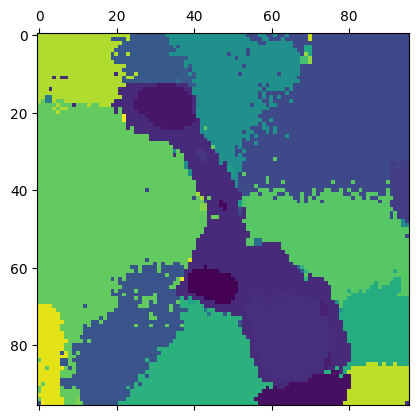

In [16]:
plt.matshow(converged_state.datapoints_state.blob_assignments.reshape((96,96)))


=== Per-Pixel Hyperblob Visualization ===


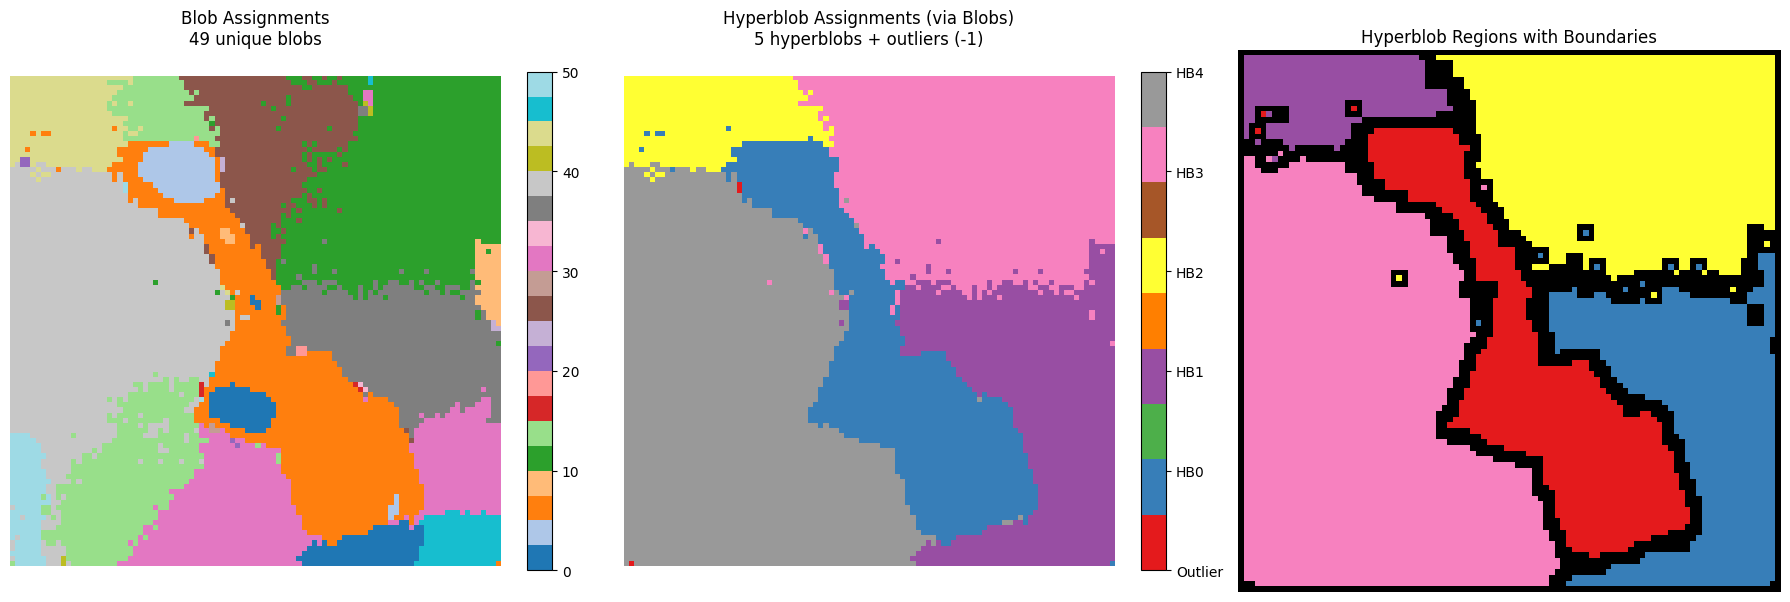


Hyperblob Statistics:
  Hyperblob 0: 1555 pixels (16.9%), 15 blobs
  Hyperblob 1: 1567 pixels (17.0%), 12 blobs
  Hyperblob 2: 592 pixels (6.4%), 3 blobs
  Hyperblob 3: 2173 pixels (23.6%), 9 blobs
  Hyperblob 4: 3326 pixels (36.1%), 11 blobs
  Outliers: 3 pixels (0.0%)

Hyperblob Weights:
  Hyperblob 0: weight = 0.200
  Hyperblob 1: weight = 0.150
  Hyperblob 2: weight = 0.181
  Hyperblob 3: weight = 0.235
  Hyperblob 4: weight = 0.234


In [17]:
# ========================================
# Additional Visualization: Per-Pixel Hyperblob Assignments
# ========================================
print("\n=== Per-Pixel Hyperblob Visualization ===")

# Get blob assignments for each datapoint
blob_assignments = np.array(converged_state.datapoints_state.blob_assignments)

# Get hyperblob assignment for each blob
blob_to_hyperblob = np.array(converged_state.blobs_state.hyperblob_assignments)

# Create per-pixel hyperblob assignments
# For each pixel, look up its blob, then look up that blob's hyperblob
pixel_hyperblobs = np.zeros_like(blob_assignments)
for i in range(len(blob_assignments)):
    blob_id = blob_assignments[i]
    # If it's an outlier (blob_id == n_blobs), assign to a special category
    if blob_id < number_of_blobs:
        pixel_hyperblobs[i] = blob_to_hyperblob[blob_id]
    else:
        # Outliers get assigned to -1 or a special value
        pixel_hyperblobs[i] = -1

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Blob assignments
blob_map = blob_assignments.reshape((96, 96))
im0 = axes[0].matshow(blob_map, cmap='tab20')
axes[0].set_title(f'Blob Assignments\n{len(np.unique(blob_assignments))} unique blobs')
axes[0].axis('off')
plt.colorbar(im0, ax=axes[0], fraction=0.046)

# Hyperblob assignments (through blob mapping)
hyperblob_map = pixel_hyperblobs.reshape((96, 96))
# Use a discrete colormap for hyperblobs
im1 = axes[1].matshow(hyperblob_map, cmap='Set1', vmin=-1, vmax=number_of_hyperblobs-1)
axes[1].set_title(f'Hyperblob Assignments (via Blobs)\n{number_of_hyperblobs} hyperblobs + outliers (-1)')
axes[1].axis('off')
cbar1 = plt.colorbar(im1, ax=axes[1], fraction=0.046)
cbar1.set_ticks(range(-1, number_of_hyperblobs))
cbar1.set_ticklabels(['Outlier'] + [f'HB{i}' for i in range(number_of_hyperblobs)])

# Combined visualization: show blob boundaries overlaid on hyperblobs
from scipy.ndimage import sobel
hyperblob_map_float = hyperblob_map.astype(float)
# Find edges in hyperblob assignments
edges_y = sobel(hyperblob_map_float, axis=0, mode='constant')
edges_x = sobel(hyperblob_map_float, axis=1, mode='constant')
edges = np.hypot(edges_x, edges_y)

# Create RGB image
import matplotlib.cm as cm
hyperblob_colors = cm.Set1(hyperblob_map / number_of_hyperblobs)[:, :, :3]
# Overlay edges
edge_threshold = 0.1
edge_mask = edges > edge_threshold
hyperblob_colors[edge_mask] = [0, 0, 0]  # Black boundaries

axes[2].imshow(hyperblob_colors)
axes[2].set_title('Hyperblob Regions with Boundaries')
axes[2].axis('off')

plt.tight_layout()
plt.show()

# Print statistics
print(f"\nHyperblob Statistics:")
for hb_id in range(number_of_hyperblobs):
    n_pixels = np.sum(pixel_hyperblobs == hb_id)
    pct = 100 * n_pixels / len(pixel_hyperblobs)
    n_blobs_in_hb = np.sum(blob_to_hyperblob == hb_id)
    print(f"  Hyperblob {hb_id}: {n_pixels} pixels ({pct:.1f}%), {n_blobs_in_hb} blobs")

n_outlier_pixels = np.sum(pixel_hyperblobs == -1)
pct_outlier = 100 * n_outlier_pixels / len(pixel_hyperblobs)
print(f"  Outliers: {n_outlier_pixels} pixels ({pct_outlier:.1f}%)")

# Show hyperblob weights
print(f"\nHyperblob Weights:")
hyperblob_weights = np.array(converged_state.hyperblobs_state.hyperblob_weights)
for hb_id in range(number_of_hyperblobs):
    print(f"  Hyperblob {hb_id}: weight = {hyperblob_weights[hb_id]:.3f}")

In [18]:
# # ========================================
# # Additional Visualization: Per-Pixel Hyperblob Assignments
# # ========================================
# print("\n=== Per-Pixel Hyperblob Visualization ===")

# # Get blob assignments for each datapoint
# blob_assignments = np.array(converged_state_frame2.datapoints_state.blob_assignments)

# # Get hyperblob assignment for each blob
# blob_to_hyperblob = np.array(converged_state_frame2.blobs_state.hyperblob_assignments)

# # Create per-pixel hyperblob assignments
# # For each pixel, look up its blob, then look up that blob's hyperblob
# pixel_hyperblobs = np.zeros_like(blob_assignments)
# for i in range(len(blob_assignments)):
#     blob_id = blob_assignments[i]
#     # If it's an outlier (blob_id == n_blobs), assign to a special category
#     if blob_id < number_of_blobs:
#         pixel_hyperblobs[i] = blob_to_hyperblob[blob_id]
#     else:
#         # Outliers get assigned to -1 or a special value
#         pixel_hyperblobs[i] = -1

# # Visualize
# fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# # Blob assignments
# blob_map = blob_assignments.reshape((96, 96))
# im0 = axes[0].matshow(blob_map, cmap='tab20')
# axes[0].set_title(f'Blob Assignments\n{len(np.unique(blob_assignments))} unique blobs')
# axes[0].axis('off')
# plt.colorbar(im0, ax=axes[0], fraction=0.046)

# # Hyperblob assignments (through blob mapping)
# hyperblob_map = pixel_hyperblobs.reshape((96, 96))
# # Use a discrete colormap for hyperblobs
# im1 = axes[1].matshow(hyperblob_map, cmap='Set1', vmin=-1, vmax=number_of_hyperblobs-1)
# axes[1].set_title(f'Hyperblob Assignments (via Blobs)\n{number_of_hyperblobs} hyperblobs + outliers (-1)')
# axes[1].axis('off')
# cbar1 = plt.colorbar(im1, ax=axes[1], fraction=0.046)
# cbar1.set_ticks(range(-1, number_of_hyperblobs))
# cbar1.set_ticklabels(['Outlier'] + [f'HB{i}' for i in range(number_of_hyperblobs)])

# # Combined visualization: show blob boundaries overlaid on hyperblobs
# from scipy.ndimage import sobel
# hyperblob_map_float = hyperblob_map.astype(float)
# # Find edges in hyperblob assignments
# edges_y = sobel(hyperblob_map_float, axis=0, mode='constant')
# edges_x = sobel(hyperblob_map_float, axis=1, mode='constant')
# edges = np.hypot(edges_x, edges_y)

# # Create RGB image
# import matplotlib.cm as cm
# hyperblob_colors = cm.Set1(hyperblob_map / number_of_hyperblobs)[:, :, :3]
# # Overlay edges
# edge_threshold = 0.1
# edge_mask = edges > edge_threshold
# hyperblob_colors[edge_mask] = [0, 0, 0]  # Black boundaries

# axes[2].imshow(hyperblob_colors)
# axes[2].set_title('Hyperblob Regions with Boundaries')
# axes[2].axis('off')

# plt.tight_layout()
# plt.show()

# # Print statistics
# print(f"\nHyperblob Statistics:")
# for hb_id in range(number_of_hyperblobs):
#     n_pixels = np.sum(pixel_hyperblobs == hb_id)
#     pct = 100 * n_pixels / len(pixel_hyperblobs)
#     n_blobs_in_hb = np.sum(blob_to_hyperblob == hb_id)
#     print(f"  Hyperblob {hb_id}: {n_pixels} pixels ({pct:.1f}%), {n_blobs_in_hb} blobs")

# n_outlier_pixels = np.sum(pixel_hyperblobs == -1)
# pct_outlier = 100 * n_outlier_pixels / len(pixel_hyperblobs)
# print(f"  Outliers: {n_outlier_pixels} pixels ({pct_outlier:.1f}%)")

# # Show hyperblob weights
# print(f"\nHyperblob Weights:")
# hyperblob_weights = np.array(converged_state_frame2.hyperblobs_state.hyperblob_weights)
# for hb_id in range(number_of_hyperblobs):
#     print(f"  Hyperblob {hb_id}: weight = {hyperblob_weights[hb_id]:.3f}")

In [19]:
# ========================================
# STEP 6.6: COMMENTED OUT - Full Gibbs Sampling on Third Frame
# ========================================
# NOTE: This cell is commented out to use tracking Gibbs instead (see new cell below)

# ========================================
# STEP 6.6: Full Gibbs Sampling on Third Frame
# ========================================
# print(f"\n=== STEP 6.6: Running full Gibbs sampling on third frame ===")

# Prepare third frame data
# third_frame_positions = points_3d[2]  # Shape: (N, 3)
# third_frame_velocities = motion_3d[1]  # Motion from frame 1 to frame 2

# print(f"Third frame positions: {third_frame_positions.shape}")
# print(f"Third frame velocities: {third_frame_velocities.shape}")

# Create updated state with third frame data
# We'll use the converged blob/hyperblob structure from frame 2, but update datapoints
# third_frame_state = HDGMM_State(
#     hypers=converged_state_frame2.hypers,
#     hyperblobs_state=converged_state_frame2.hyperblobs_state,
#     blobs_state=converged_state_frame2.blobs_state,
#     datapoints_state=HDGMM_Datapoints_State(
#         blob_assignments=converged_state_frame2.datapoints_state.blob_assignments,  # Start with frame 2 assignments
#         datapoint_positions=jnp.array(third_frame_positions),  # NEW: third frame positions
#         datapoint_vels=jnp.array(third_frame_velocities)  # NEW: third frame velocities
#     )
# )

# print(f"✓ Third frame state initialized from converged second frame state")

# Run full Gibbs sampling on third frame
# num_gibbs_iterations_frame3 = 500
# num_inner_loops_frame3 = 5
# print(f"Running {num_gibbs_iterations_frame3} Gibbs iterations on third frame...")

# key, gibbs_key_frame3 = jax.random.split(key)
# gibbs_wtrs_frame3 = hdgmm_full_gibbs(
#     gibbs_key_frame3, third_frame_state, num_gibbs_iterations_frame3,
#     GIBBS_DIALS, use_weighted_blobs=True, num_gibbs_inner_loops=num_inner_loops_frame3
# )

# print(f"✓ Third frame Gibbs sampling complete: {len(gibbs_wtrs_frame3)} samples")

# Get final converged state for third frame
# converged_state_frame3 = gibbs_wtrs_frame3[-1].retval

# ========================================
# Visualization: Compare All Three Frames
# ========================================
# print(f"\n=== Comparing All Three Frames ===")

# fig = plt.figure(figsize=(20, 12))

# ---------- CONVERGENCE METRICS ----------
# sample_freq = max(1, len(gibbs_wtrs) // 50)
# n_blobs_history_f1 = []
# blob_weight_entropy_f1 = []
# n_blobs_history_f2 = []
# blob_weight_entropy_f2 = []
# n_blobs_history_f3 = []
# blob_weight_entropy_f3 = []

# for idx in range(0, len(gibbs_wtrs), sample_freq):
#     state = gibbs_wtrs[idx].retval
#     blob_assigns = np.array(state.datapoints_state.blob_assignments)
#     blob_weights = np.array(state.blobs_state.blob_weights)
#     unique_blobs = len(np.unique(blob_assigns))
#     n_blobs_history_f1.append(unique_blobs)
#     weight_probs = blob_weights / blob_weights.sum()
#     entropy = -np.sum(weight_probs * np.log(weight_probs + 1e-10))
#     blob_weight_entropy_f1.append(entropy)

# for idx in range(0, len(gibbs_wtrs_frame2), sample_freq):
#     state = gibbs_wtrs_frame2[idx].retval
#     blob_assigns = np.array(state.datapoints_state.blob_assignments)
#     blob_weights = np.array(state.blobs_state.blob_weights)
#     unique_blobs = len(np.unique(blob_assigns))
#     n_blobs_history_f2.append(unique_blobs)
#     weight_probs = blob_weights / blob_weights.sum()
#     entropy = -np.sum(weight_probs * np.log(weight_probs + 1e-10))
#     blob_weight_entropy_f2.append(entropy)

# for idx in range(0, len(gibbs_wtrs_frame3), sample_freq):
#     state = gibbs_wtrs_frame3[idx].retval
#     blob_assigns = np.array(state.datapoints_state.blob_assignments)
#     blob_weights = np.array(state.blobs_state.blob_weights)
#     unique_blobs = len(np.unique(blob_assigns))
#     n_blobs_history_f3.append(unique_blobs)
#     weight_probs = blob_weights / blob_weights.sum()
#     entropy = -np.sum(weight_probs * np.log(weight_probs + 1e-10))
#     blob_weight_entropy_f3.append(entropy)

# Plot convergence comparison
# iterations = np.arange(0, len(gibbs_wtrs), sample_freq)
# iterations_f2 = np.arange(0, len(gibbs_wtrs_frame2), sample_freq)
# iterations_f3 = np.arange(0, len(gibbs_wtrs_frame3), sample_freq)

# ax1 = plt.subplot(2, 3, 1)
# ax1.plot(iterations, n_blobs_history_f1, 'b-', linewidth=2, label='Frame 1', alpha=0.7)
# ax1.plot(iterations_f2, n_blobs_history_f2, 'r-', linewidth=2, label='Frame 2', alpha=0.7)
# ax1.plot(iterations_f3, n_blobs_history_f3, 'g-', linewidth=2, label='Frame 3', alpha=0.7)
# ax1.set_xlabel('Iteration')
# ax1.set_ylabel('Unique Blobs Used')
# ax1.set_title('Number of Active Blobs Over Time')
# ax1.legend()
# ax1.grid(True, alpha=0.3)

# ax2 = plt.subplot(2, 3, 2)
# ax2.plot(iterations, blob_weight_entropy_f1, 'b-', linewidth=2, label='Frame 1', alpha=0.7)
# ax2.plot(iterations_f2, blob_weight_entropy_f2, 'r-', linewidth=2, label='Frame 2', alpha=0.7)
# ax2.plot(iterations_f3, blob_weight_entropy_f3, 'g-', linewidth=2, label='Frame 3', alpha=0.7)
# ax2.set_xlabel('Iteration')
# ax2.set_ylabel('Entropy (nats)')
# ax2.set_title('Blob Weight Entropy Over Time')
# ax2.legend()
# ax2.grid(True, alpha=0.3)

# ---------- 3D VISUALIZATIONS ----------
# final_blob_assigns_f1 = np.array(converged_state.datapoints_state.blob_assignments)
# final_blob_means_f1 = np.array(converged_state.blobs_state.blob_means)

# final_blob_assigns_f2 = np.array(converged_state_frame2.datapoints_state.blob_assignments)
# final_blob_means_f2 = np.array(converged_state_frame2.blobs_state.blob_means)

# final_blob_assigns_f3 = np.array(converged_state_frame3.datapoints_state.blob_assignments)
# final_blob_means_f3 = np.array(converged_state_frame3.blobs_state.blob_means)

# np.random.seed(42)
# blob_colors = np.random.rand(number_of_blobs, 3)
# stride = max(1, len(points_3d[0]) // 3000)

# Frame 1
# ax3 = fig.add_subplot(2, 3, 3, projection='3d')
# pts_f1 = points_3d[0][::stride]
# assigns_f1 = final_blob_assigns_f1[::stride]
# outlier_mask_f1 = assigns_f1 == number_of_blobs
# inlier_pts_f1 = pts_f1[~outlier_mask_f1]
# inlier_assigns_f1 = assigns_f1[~outlier_mask_f1]
# if len(inlier_pts_f1) > 0:
#     point_colors_f1 = blob_colors[inlier_assigns_f1]
#     ax3.scatter(inlier_pts_f1[:, 0], inlier_pts_f1[:, 1], inlier_pts_f1[:, 2], 
#                 c=point_colors_f1, s=2, alpha=0.5)
# ax3.scatter(final_blob_means_f1[:, 0], final_blob_means_f1[:, 1], final_blob_means_f1[:, 2],
#             c='red', s=100, marker='X', edgecolors='black', linewidths=2)
# ax3.set_xlabel('X')
# ax3.set_ylabel('Y')
# ax3.set_zlabel('Z')
# ax3.set_title(f'Frame 1: {len(np.unique(inlier_assigns_f1))} blobs')

# Frame 2
# ax4 = fig.add_subplot(2, 3, 4, projection='3d')
# pts_f2 = points_3d[1][::stride]
# assigns_f2 = final_blob_assigns_f2[::stride]
# outlier_mask_f2 = assigns_f2 == number_of_blobs
# inlier_pts_f2 = pts_f2[~outlier_mask_f2]
# inlier_assigns_f2 = assigns_f2[~outlier_mask_f2]
# if len(inlier_pts_f2) > 0:
#     point_colors_f2 = blob_colors[inlier_assigns_f2]
#     ax4.scatter(inlier_pts_f2[:, 0], inlier_pts_f2[:, 1], inlier_pts_f2[:, 2],
#                 c=point_colors_f2, s=2, alpha=0.5)
# ax4.scatter(final_blob_means_f2[:, 0], final_blob_means_f2[:, 1], final_blob_means_f2[:, 2],
#             c='red', s=100, marker='X', edgecolors='black', linewidths=2)
# ax4.set_xlabel('X')
# ax4.set_ylabel('Y')
# ax4.set_zlabel('Z')
# ax4.set_title(f'Frame 2: {len(np.unique(inlier_assigns_f2))} blobs')

# Frame 3
# ax5 = fig.add_subplot(2, 3, 5, projection='3d')
# pts_f3 = points_3d[2][::stride]
# assigns_f3 = final_blob_assigns_f3[::stride]
# outlier_mask_f3 = assigns_f3 == number_of_blobs
# inlier_pts_f3 = pts_f3[~outlier_mask_f3]
# inlier_assigns_f3 = assigns_f3[~outlier_mask_f3]
# if len(inlier_pts_f3) > 0:
#     point_colors_f3 = blob_colors[inlier_assigns_f3]
#     ax5.scatter(inlier_pts_f3[:, 0], inlier_pts_f3[:, 1], inlier_pts_f3[:, 2],
#                 c=point_colors_f3, s=2, alpha=0.5)
# ax5.scatter(final_blob_means_f3[:, 0], final_blob_means_f3[:, 1], final_blob_means_f3[:, 2],
#             c='red', s=100, marker='X', edgecolors='black', linewidths=2)
# ax5.set_xlabel('X')
# ax5.set_ylabel('Y')
# ax5.set_zlabel('Z')
# ax5.set_title(f'Frame 3: {len(np.unique(inlier_assigns_f3))} blobs')

# Blob trajectories over 3 frames
# ax6 = fig.add_subplot(2, 3, 6, projection='3d')
# for blob_id in range(number_of_blobs):
#     trajectory = np.array([
#         final_blob_means_f1[blob_id],
#         final_blob_means_f2[blob_id],
#         final_blob_means_f3[blob_id]
#     ])
#     ax6.plot(trajectory[:, 0], trajectory[:, 1], trajectory[:, 2], 
#              color=blob_colors[blob_id], alpha=0.3, linewidth=1)

# Mark start and end
# ax6.scatter(final_blob_means_f1[:, 0], final_blob_means_f1[:, 1], final_blob_means_f1[:, 2],
#             c='blue', s=50, marker='o', edgecolors='black', linewidths=1, alpha=0.7, label='Frame 1')
# ax6.scatter(final_blob_means_f3[:, 0], final_blob_means_f3[:, 1], final_blob_means_f3[:, 2],
#             c='green', s=50, marker='s', edgecolors='black', linewidths=1, alpha=0.7, label='Frame 3')
# ax6.set_xlabel('X')
# ax6.set_ylabel('Y')
# ax6.set_zlabel('Z')
# ax6.set_title('Blob Center Trajectories (Frame 1 → 2 → 3)')
# ax6.legend()

# plt.tight_layout()
# plt.show()

# print(f"\n✓ Three-frame comparison complete")
# print(f"Frame 1: {len(np.unique(final_blob_assigns_f1[final_blob_assigns_f1 < number_of_blobs]))} active blobs")
# print(f"Frame 2: {len(np.unique(final_blob_assigns_f2[final_blob_assigns_f2 < number_of_blobs]))} active blobs")
# print(f"Frame 3: {len(np.unique(final_blob_assigns_f3[final_blob_assigns_f3 < number_of_blobs]))} active blobs")

print('✓ Cell 22 commented out - using tracking Gibbs instead')

✓ Cell 22 commented out - using tracking Gibbs instead


In [20]:
# # ========================================
# # Per-Pixel Hyperblob Visualization for Frame 3
# # ========================================
# print("\n=== Per-Pixel Hyperblob Visualization (Frame 3) ===")

# # Get blob assignments for each datapoint (Frame 3)
# blob_assignments = np.array(converged_state_frame3.datapoints_state.blob_assignments)

# # Get hyperblob assignment for each blob
# blob_to_hyperblob = np.array(converged_state_frame3.blobs_state.hyperblob_assignments)

# # Create per-pixel hyperblob assignments
# # For each pixel, look up its blob, then look up that blob's hyperblob
# pixel_hyperblobs = np.zeros_like(blob_assignments)
# for i in range(len(blob_assignments)):
#     blob_id = blob_assignments[i]
#     # If it's an outlier (blob_id == n_blobs), assign to a special category
#     if blob_id < number_of_blobs:
#         pixel_hyperblobs[i] = blob_to_hyperblob[blob_id]
#     else:
#         # Outliers get assigned to -1 or a special value
#         pixel_hyperblobs[i] = -1

# # Visualize
# fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# # Blob assignments
# blob_map = blob_assignments.reshape((96, 96))
# im0 = axes[0].matshow(blob_map, cmap='tab20')
# axes[0].set_title(f'Blob Assignments (Frame 3)\n{len(np.unique(blob_assignments))} unique blobs')
# axes[0].axis('off')
# plt.colorbar(im0, ax=axes[0], fraction=0.046)

# # Hyperblob assignments (through blob mapping)
# hyperblob_map = pixel_hyperblobs.reshape((96, 96))
# # Use a discrete colormap for hyperblobs
# im1 = axes[1].matshow(hyperblob_map, cmap='Set1', vmin=-1, vmax=number_of_hyperblobs-1)
# axes[1].set_title(f'Hyperblob Assignments (Frame 3)\n{number_of_hyperblobs} hyperblobs + outliers (-1)')
# axes[1].axis('off')
# cbar1 = plt.colorbar(im1, ax=axes[1], fraction=0.046)
# cbar1.set_ticks(range(-1, number_of_hyperblobs))
# cbar1.set_ticklabels(['Outlier'] + [f'HB{i}' for i in range(number_of_hyperblobs)])

# # Combined visualization: show blob boundaries overlaid on hyperblobs
# from scipy.ndimage import sobel
# hyperblob_map_float = hyperblob_map.astype(float)
# # Find edges in hyperblob assignments
# edges_y = sobel(hyperblob_map_float, axis=0, mode='constant')
# edges_x = sobel(hyperblob_map_float, axis=1, mode='constant')
# edges = np.hypot(edges_x, edges_y)

# # Create RGB image
# import matplotlib.cm as cm
# hyperblob_colors = cm.Set1(hyperblob_map / number_of_hyperblobs)[:, :, :3]
# # Overlay edges
# edge_threshold = 0.1
# edge_mask = edges > edge_threshold
# hyperblob_colors[edge_mask] = [0, 0, 0]  # Black boundaries

# axes[2].imshow(hyperblob_colors)
# axes[2].set_title('Hyperblob Regions with Boundaries (Frame 3)')
# axes[2].axis('off')

# plt.tight_layout()
# plt.show()

# # Print statistics
# print(f"\nHyperblob Statistics (Frame 3):")
# for hb_id in range(number_of_hyperblobs):
#     n_pixels = np.sum(pixel_hyperblobs == hb_id)
#     pct = 100 * n_pixels / len(pixel_hyperblobs)
#     n_blobs_in_hb = np.sum(blob_to_hyperblob == hb_id)
#     print(f"  Hyperblob {hb_id}: {n_pixels} pixels ({pct:.1f}%), {n_blobs_in_hb} blobs")

# n_outlier_pixels = np.sum(pixel_hyperblobs == -1)
# pct_outlier = 100 * n_outlier_pixels / len(pixel_hyperblobs)
# print(f"  Outliers: {n_outlier_pixels} pixels ({pct_outlier:.1f}%)")

# # Show hyperblob weights
# print(f"\nHyperblob Weights (Frame 3):")
# hyperblob_weights = np.array(converged_state_frame3.hyperblobs_state.hyperblob_weights)
# for hb_id in range(number_of_hyperblobs):
#     print(f"  Hyperblob {hb_id}: weight = {hyperblob_weights[hb_id]:.3f}")

In [21]:
# ========================================
# STEP 6.7: COMMENTED OUT - Full Gibbs Sampling on Frames 4-11
# ========================================
# NOTE: This cell is commented out to use tracking Gibbs instead (see new cell below)

# ========================================
# STEP 6.7: Full Gibbs Sampling on Frames 4-11 (8 more frames)
# ========================================
# print(f"\n=== STEP 6.7: Running full Gibbs sampling on 8 more frames (4-11) ===")

# Store all converged states
# all_converged_states = [converged_state, converged_state_frame2, converged_state_frame3]
# all_gibbs_wtrs = [gibbs_wtrs, gibbs_wtrs_frame2, gibbs_wtrs_frame3]

# Process frames 4-11
# for frame_idx in range(3, 11):
#     print(f"\n--- Processing Frame {frame_idx + 1} ---")
    
    # Prepare frame data
#     frame_positions = points_3d[frame_idx]
#     frame_velocities = motion_3d[frame_idx - 1]  # Motion from previous frame to current
    
#     print(f"Frame {frame_idx + 1} positions: {frame_positions.shape}")
#     print(f"Frame {frame_idx + 1} velocities: {frame_velocities.shape}")
    
    # Create updated state from previous frame
#     prev_state = all_converged_states[-1]
#     current_frame_state = HDGMM_State(
#         hypers=prev_state.hypers,
#         hyperblobs_state=prev_state.hyperblobs_state,
#         blobs_state=prev_state.blobs_state,
#         datapoints_state=HDGMM_Datapoints_State(
#             blob_assignments=prev_state.datapoints_state.blob_assignments,
#             datapoint_positions=jnp.array(frame_positions),
#             datapoint_vels=jnp.array(frame_velocities)
#         )
#     )
    
#     print(f"✓ Frame {frame_idx + 1} state initialized from frame {frame_idx}")
    
    # Run full Gibbs sampling
#     num_gibbs_iterations = 1000
#     num_inner_loops = 5
#     print(f"Running {num_gibbs_iterations} Gibbs iterations...")
    
#     key, gibbs_key = jax.random.split(key)
#     gibbs_wtrs_current = hdgmm_full_gibbs(
#         gibbs_key, current_frame_state, num_gibbs_iterations,
#         GIBBS_DIALS, use_weighted_blobs=True, num_gibbs_inner_loops=num_inner_loops
#     )
    
#     print(f"✓ Frame {frame_idx + 1} Gibbs sampling complete: {len(gibbs_wtrs_current)} samples")
    
    # Store results
#     converged_state_current = gibbs_wtrs_current[-1].retval
#     all_converged_states.append(converged_state_current)
#     all_gibbs_wtrs.append(gibbs_wtrs_current)
    
    # Quick stats
#     final_assigns = np.array(converged_state_current.datapoints_state.blob_assignments)
#     n_active_blobs = len(np.unique(final_assigns[final_assigns < number_of_blobs]))
#     n_outliers = np.sum(final_assigns == number_of_blobs)
#     pct_outliers = 100 * n_outliers / len(final_assigns)
#     print(f"  Active blobs: {n_active_blobs}/{number_of_blobs}")
#     print(f"  Outliers: {n_outliers} ({pct_outliers:.1f}%)")

# print(f"\n{'='*60}")
# print(f"✓ ALL FRAMES COMPLETE: Processed {len(all_converged_states)} frames total")
# print(f"{'='*60}")

print('✓ Cell 24 commented out - using tracking Gibbs instead')

✓ Cell 24 commented out - using tracking Gibbs instead


In [22]:
points_3d[1:11].shape

(10, 9216, 3)

In [23]:
# ========================================
# STEP 6.5-6.7 REPLACEMENT: Tracking Gibbs Sampling for Frames 2-11
# ========================================
print(f"\n=== STEP 6.5-6.7: Running tracking Gibbs sampling on frames 2-11 ===")

# Use converged state from frame 1 as initial state
init_tracking_state = converged_state

# Run tracking Gibbs over all remaining frames (2-11)

key, tracking_key = jax.random.split(key)
print(f"Running tracking Gibbs on frames 2-11 (using frame 1 as initialization)...")

# Note: tracking_gibbs expects frames starting from frame 2 onwards
tracking_points = points_3d[1:12]  # Frames 2-11
tracking_motion = motion_3d[1:12]  # Motion vectors for frames 2-11

print(f"Points 3D shape: {tracking_points.shape}")
print(f"Motion 3D shape: {tracking_motion.shape}")


tracking_wtrs = hdgmm_tracking_gibbs(
    tracking_key,
    init_tracking_state,
    tracking_points,  # Frames 2-11
    tracking_motion   # Motion vectors for frames 2-11
)

print(f"✓ Tracking Gibbs complete: {len(tracking_wtrs)} frames tracked")

# ========================================
# Extract tracking data for visualization
# ========================================
# Extract tracking data for visualization
tracking_data = []
for i in range(len(tracking_wtrs)):
    wtr = tracking_wtrs[i]
    blob_assignments = np.array(wtr.retval.datapoints_state.blob_assignments)
    n_blobs = wtr.retval.hypers.n_blobs
    blob_weights = np.array(wtr.retval.blobs_state.blob_weights)
    blob_means = np.array(wtr.retval.blobs_state.blob_means)
    hyperblob_assignments = np.array(wtr.retval.blobs_state.hyperblob_assignments)
    
    frame_data = {
        'n_blobs': n_blobs,
        'blob_assignments': blob_assignments,
        'blob_weights': blob_weights,
        'blob_means': blob_means,
        'hyperblob_assignments': hyperblob_assignments
    }
    tracking_data.append(frame_data)



=== STEP 6.5-6.7: Running tracking Gibbs sampling on frames 2-11 ===
Running tracking Gibbs on frames 2-11 (using frame 1 as initialization)...
Points 3D shape: (11, 9216, 3)
Motion 3D shape: (11, 9216, 3)
✓ Tracking Gibbs complete: 10 frames tracked


In [ ]:
# there's a bug with how this trace is accessed .... 

In [ ]:
# ========================================
# Visualization: Tracking Results Over Time
# ========================================
print(f"\n=== Visualizing Tracking Results ===")

fig = plt.figure(figsize=(20, 15))

# ---------- TRACKING METRICS OVER TIME ----------
n_active_blobs_over_time = []
n_outliers_over_time = []
blob_weight_entropy_over_time = []

for state in all_converged_states:
    blob_assigns = np.array(state.datapoints_state.blob_assignments)
    blob_weights = np.array(state.blobs_state.blob_weights)

    n_active = len(np.unique(blob_assigns[blob_assigns < number_of_blobs]))
    n_outliers = np.sum(blob_assigns == number_of_blobs)

    weight_probs = blob_weights / blob_weights.sum()
    entropy = -np.sum(weight_probs * np.log(weight_probs + 1e-10))

    n_active_blobs_over_time.append(n_active)
    n_outliers_over_time.append(n_outliers)
    blob_weight_entropy_over_time.append(entropy)

frames = np.arange(1, len(all_converged_states) + 1)

# Plot 1: Active blobs over time
ax1 = plt.subplot(3, 3, 1)
ax1.plot(frames, n_active_blobs_over_time, 'b-o', linewidth=2, markersize=5)
ax1.set_xlabel('Frame Number')
ax1.set_ylabel('Active Blobs')
ax1.set_title('Number of Active Blobs Over Time')
ax1.grid(True, alpha=0.3)
ax1.set_xticks(frames)

# Plot 2: Outliers over time
ax2 = plt.subplot(3, 3, 2)
ax2.plot(frames, n_outliers_over_time, 'r-o', linewidth=2, markersize=5)
ax2.set_xlabel('Frame Number')
ax2.set_ylabel('Number of Outliers')
ax2.set_title('Outliers Over Time')
ax2.grid(True, alpha=0.3)
ax2.set_xticks(frames)

# Plot 3: Blob weight entropy over time
ax3 = plt.subplot(3, 3, 3)
ax3.plot(frames, blob_weight_entropy_over_time, 'g-o', linewidth=2, markersize=5)
ax3.set_xlabel('Frame Number')
ax3.set_ylabel('Entropy (nats)')
ax3.set_title('Blob Weight Entropy Over Time')
ax3.grid(True, alpha=0.3)
ax3.set_xticks(frames)

# ---------- 3D VISUALIZATIONS FOR SELECTED FRAMES ----------
# Show frames 1, 6, and 11
selected_frames = [0, 5, 10]  # Indices for frames 1, 6, 11
np.random.seed(42)
blob_colors = np.random.rand(number_of_blobs, 3)
stride = max(1, len(points_3d[0]) // 3000)

for plot_idx, frame_idx in enumerate(selected_frames):
    ax = fig.add_subplot(3, 3, 4 + plot_idx, projection='3d')

    state = all_converged_states[frame_idx]
    pts = points_3d[frame_idx][::stride]
    assigns = np.array(state.datapoints_state.blob_assignments)[::stride]
    blob_means = np.array(state.blobs_state.blob_means)

    outlier_mask = assigns == number_of_blobs
    inlier_pts = pts[~outlier_mask]
    inlier_assigns = assigns[~outlier_mask]
    outlier_pts = pts[outlier_mask]

    if len(inlier_pts) > 0:
        point_colors = blob_colors[inlier_assigns]
        ax.scatter(inlier_pts[:, 0], inlier_pts[:, 1], inlier_pts[:, 2],
                   c=point_colors, s=2, alpha=0.5)

    if len(outlier_pts) > 0:
        ax.scatter(outlier_pts[:, 0], outlier_pts[:, 1], outlier_pts[:, 2],
                   c='black', s=3, alpha=0.8, marker='x', label='Outliers')

    ax.scatter(blob_means[:, 0], blob_means[:, 1], blob_means[:, 2],
               c='red', s=100, marker='X', edgecolors='black', linewidths=2, label='Blob centers')

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title(f'Frame {frame_idx + 1}: {len(np.unique(inlier_assigns))} blobs')
    if len(outlier_pts) > 0:
        ax.legend()

# ---------- BLOB CENTER TRAJECTORIES ----------
ax7 = fig.add_subplot(3, 3, 7, projection='3d')

# Extract blob center trajectories
all_blob_means = [np.array(state.blobs_state.blob_means) for state in all_converged_states]

# Plot trajectory for each blob
for blob_id in range(number_of_blobs):
    trajectory = np.array([means[blob_id] for means in all_blob_means])
    ax7.plot(trajectory[:, 0], trajectory[:, 1], trajectory[:, 2],
             color=blob_colors[blob_id], alpha=0.3, linewidth=1)

# Mark start and end points
first_means = all_blob_means[0]
last_means = all_blob_means[-1]

ax7.scatter(first_means[:, 0], first_means[:, 1], first_means[:, 2],
            c='blue', s=80, marker='o', edgecolors='black', linewidths=1.5, alpha=0.8, label='Frame 1')
ax7.scatter(last_means[:, 0], last_means[:, 1], last_means[:, 2],
            c='green', s=80, marker='s', edgecolors='black', linewidths=1.5, alpha=0.8, label=f'Frame {len(all_converged_states)}')

ax7.set_xlabel('X')
ax7.set_ylabel('Y')
ax7.set_zlabel('Z')
ax7.set_title('Blob Center Trajectories (All Frames)')
ax7.legend()

# ---------- BLOB DISPLACEMENT ANALYSIS ----------
ax8 = plt.subplot(3, 3, 8)

# Calculate frame-to-frame displacement for each blob
blob_displacements = []
for i in range(len(all_blob_means) - 1):
    displacement = np.linalg.norm(all_blob_means[i+1] - all_blob_means[i], axis=1)
    blob_displacements.append(displacement.mean())

ax8.plot(frames[:-1], blob_displacements, 'purple', linewidth=2, marker='o', markersize=6)
ax8.set_xlabel('Frame Transition')
ax8.set_ylabel('Mean Blob Displacement')
ax8.set_title('Average Blob Motion Between Frames')
ax8.grid(True, alpha=0.3)
ax8.set_xticks(frames[:-1])

# ---------- BLOB ASSIGNMENT STABILITY ----------
ax9 = plt.subplot(3, 3, 9)

# Calculate percentage of points that changed blob assignment between frames
assignment_changes = []
for i in range(len(all_converged_states) - 1):
    assigns_prev = np.array(all_converged_states[i].datapoints_state.blob_assignments)
    assigns_curr = np.array(all_converged_states[i+1].datapoints_state.blob_assignments)

    n_changes = np.sum(assigns_prev != assigns_curr)
    pct_changes = 100 * n_changes / len(assigns_prev)
    assignment_changes.append(pct_changes)

ax9.plot(frames[:-1], assignment_changes, 'orange', linewidth=2, marker='s', markersize=6)
ax9.set_xlabel('Frame Transition')
ax9.set_ylabel('% Points Changed Blob')
ax9.set_title('Blob Assignment Stability')
ax9.grid(True, alpha=0.3)
ax9.set_xticks(frames[:-1])

plt.tight_layout()
plt.show()

print(f"✓ Tracking visualization complete")


=== Per-Pixel Hyperblob Visualization for All 11 Frames ===

Processing visualization for Frame 1...
Frame 1 Statistics:
  Hyperblob 0: 1560 pixels (16.9%), 17 blobs
  Hyperblob 1: 1561 pixels (16.9%), 10 blobs
  Hyperblob 2: 588 pixels (6.4%), 3 blobs
  Hyperblob 3: 2183 pixels (23.7%), 10 blobs
  Hyperblob 4: 3321 pixels (36.0%), 10 blobs
  Outliers: 3 pixels (0.0%)
  Hyperblob weights: ['0.200', '0.150', '0.181', '0.235', '0.234']

Processing visualization for Frame 2...
Frame 2 Statistics:
  Hyperblob 0: 1352 pixels (14.7%), 11 blobs
  Hyperblob 1: 1596 pixels (17.3%), 10 blobs
  Hyperblob 2: 1314 pixels (14.3%), 11 blobs
  Hyperblob 3: 2215 pixels (24.0%), 13 blobs
  Hyperblob 4: 2711 pixels (29.4%), 5 blobs
  Outliers: 28 pixels (0.3%)
  Hyperblob weights: ['0.200', '0.150', '0.181', '0.235', '0.234']

Processing visualization for Frame 3...
Frame 3 Statistics:
  Hyperblob 0: 2050 pixels (22.2%), 19 blobs
  Hyperblob 1: 1625 pixels (17.6%), 8 blobs
  Hyperblob 2: 0 pixels (0.0%)

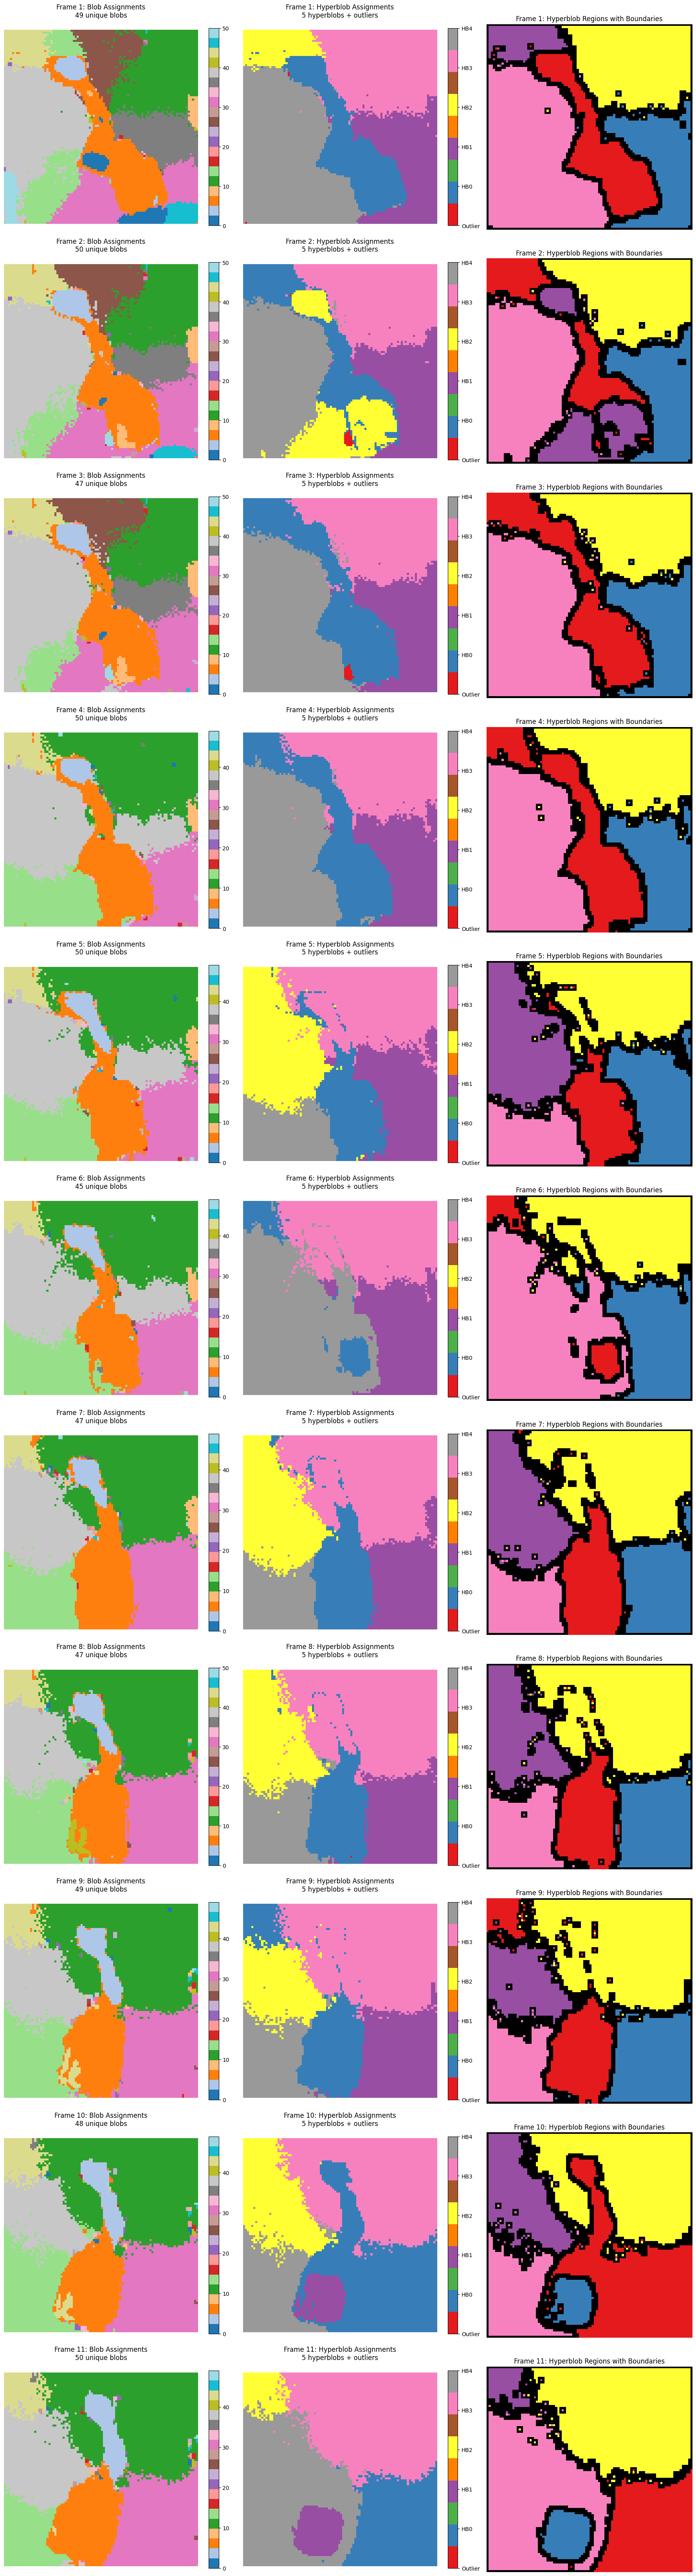


✓ Visualization complete for all 11 frames


In [ ]:
# ========================================
# Per-Pixel Hyperblob Visualization for All Frames
# ========================================
print(f"\n=== Per-Pixel Hyperblob Visualization for All {len(all_converged_states)} Frames ===")

# Create a large figure to show all frames
num_frames = len(all_converged_states)
fig, axes = plt.subplots(num_frames, 3, figsize=(18, 6 * num_frames))

# Make sure axes is 2D even if there's only one frame
if num_frames == 1:
    axes = axes.reshape(1, -1)

for frame_idx, converged_state_i in enumerate(all_converged_states):
    print(f"\nProcessing visualization for Frame {frame_idx + 1}...")
    
    # Get blob assignments for each datapoint
    blob_assignments = np.array(converged_state_i.datapoints_state.blob_assignments)
    
    # Get hyperblob assignment for each blob
    blob_to_hyperblob = np.array(converged_state_i.blobs_state.hyperblob_assignments)
    
    # Create per-pixel hyperblob assignments
    pixel_hyperblobs = np.zeros_like(blob_assignments)
    for i in range(len(blob_assignments)):
        blob_id = blob_assignments[i]
        if blob_id < number_of_blobs:
            pixel_hyperblobs[i] = blob_to_hyperblob[blob_id]
        else:
            pixel_hyperblobs[i] = -1
    
    # Blob assignments
    blob_map = blob_assignments.reshape((96, 96))
    im0 = axes[frame_idx, 0].matshow(blob_map, cmap='tab20')
    axes[frame_idx, 0].set_title(f'Frame {frame_idx + 1}: Blob Assignments\n{len(np.unique(blob_assignments))} unique blobs')
    axes[frame_idx, 0].axis('off')
    plt.colorbar(im0, ax=axes[frame_idx, 0], fraction=0.046)
    
    # Hyperblob assignments
    hyperblob_map = pixel_hyperblobs.reshape((96, 96))
    im1 = axes[frame_idx, 1].matshow(hyperblob_map, cmap='Set1', vmin=-1, vmax=number_of_hyperblobs-1)
    axes[frame_idx, 1].set_title(f'Frame {frame_idx + 1}: Hyperblob Assignments\n{number_of_hyperblobs} hyperblobs + outliers')
    axes[frame_idx, 1].axis('off')
    cbar1 = plt.colorbar(im1, ax=axes[frame_idx, 1], fraction=0.046)
    cbar1.set_ticks(range(-1, number_of_hyperblobs))
    cbar1.set_ticklabels(['Outlier'] + [f'HB{i}' for i in range(number_of_hyperblobs)])
    
    # Combined visualization with boundaries
    from scipy.ndimage import sobel
    hyperblob_map_float = hyperblob_map.astype(float)
    edges_y = sobel(hyperblob_map_float, axis=0, mode='constant')
    edges_x = sobel(hyperblob_map_float, axis=1, mode='constant')
    edges = np.hypot(edges_x, edges_y)
    
    import matplotlib.cm as cm
    hyperblob_colors = cm.Set1(hyperblob_map / number_of_hyperblobs)[:, :, :3]
    edge_threshold = 0.1
    edge_mask = edges > edge_threshold
    hyperblob_colors[edge_mask] = [0, 0, 0]
    
    axes[frame_idx, 2].imshow(hyperblob_colors)
    axes[frame_idx, 2].set_title(f'Frame {frame_idx + 1}: Hyperblob Regions with Boundaries')
    axes[frame_idx, 2].axis('off')
    
    # Print statistics for this frame
    print(f"Frame {frame_idx + 1} Statistics:")
    for hb_id in range(number_of_hyperblobs):
        n_pixels = np.sum(pixel_hyperblobs == hb_id)
        pct = 100 * n_pixels / len(pixel_hyperblobs)
        n_blobs_in_hb = np.sum(blob_to_hyperblob == hb_id)
        print(f"  Hyperblob {hb_id}: {n_pixels} pixels ({pct:.1f}%), {n_blobs_in_hb} blobs")
    
    n_outlier_pixels = np.sum(pixel_hyperblobs == -1)
    pct_outlier = 100 * n_outlier_pixels / len(pixel_hyperblobs)
    print(f"  Outliers: {n_outlier_pixels} pixels ({pct_outlier:.1f}%)")
    
    hyperblob_weights = np.array(converged_state_i.hyperblobs_state.hyperblob_weights)
    print(f"  Hyperblob weights: {[f'{w:.3f}' for w in hyperblob_weights]}")

plt.tight_layout()
plt.show()

print(f"\n{'='*60}")
print(f"✓ Visualization complete for all {num_frames} frames")
print(f"{'='*60}")

In [ ]:
# ========================================
# STEP 8: Visualize Tracking Results Over Time
# ========================================
print(f"\n=== STEP 8: Visualizing tracking results ===")

# Compute statistics over time
n_blobs_over_time = [frame['n_blobs'] for frame in tracking_data]
n_active_blobs_over_time = [len(np.unique(frame['blob_assignments'])) for frame in tracking_data]
outlier_counts_over_time = [np.sum(frame['blob_assignments'] == frame['n_blobs']) for frame in tracking_data]
outlier_pcts_over_time = [100 * outlier_counts_over_time[i] / len(tracking_data[i]['blob_assignments']) 
                          for i in range(len(tracking_data))]

# Create comprehensive visualization
fig = plt.figure(figsize=(20, 12))

# Blob count over time
ax1 = plt.subplot(3, 3, 1)
ax1.plot(n_active_blobs_over_time, 'b-', linewidth=2, label='Active blobs')
ax1.axhline(number_of_blobs, color='red', linestyle='--', label=f'Max ({number_of_blobs})')
ax1.set_xlabel('Frame')
ax1.set_ylabel('Number of Blobs')
ax1.set_title('Active Blobs Over Time')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Outlier percentage over time
ax2 = plt.subplot(3, 3, 2)
ax2.plot(outlier_pcts_over_time, 'r-', linewidth=2)
ax2.set_xlabel('Frame')
ax2.set_ylabel('Outlier %')
ax2.set_title('Outlier Percentage Over Time')
ax2.grid(True, alpha=0.3)

# Point count distribution
ax3 = plt.subplot(3, 3, 3)
blob_counts_first = np.unique(tracking_data[0]['blob_assignments'], return_counts=True)[1]
blob_counts_mid = np.unique(tracking_data[len(tracking_data)//2]['blob_assignments'], return_counts=True)[1]
blob_counts_last = np.unique(tracking_data[-1]['blob_assignments'], return_counts=True)[1]
ax3.hist(blob_counts_first, bins=30, alpha=0.5, label='Frame 0')
ax3.hist(blob_counts_mid, bins=30, alpha=0.5, label=f'Frame {len(tracking_data)//2}')
ax3.hist(blob_counts_last, bins=30, alpha=0.5, label=f'Frame {len(tracking_data)-1}')
ax3.set_xlabel('Points per Blob')
ax3.set_ylabel('Count')
ax3.set_title('Blob Size Distribution')
ax3.legend()
ax3.set_yscale('log')

# 3D visualizations for first, middle, last frames
frames_to_viz = [0, len(tracking_data)//2, len(tracking_data)-1]
np.random.seed(42)
blob_colors = np.random.rand(number_of_blobs, 3)

for idx, frame_idx in enumerate(frames_to_viz):
    ax = fig.add_subplot(3, 3, 4 + idx, projection='3d')
    
    stride = max(1, len(points_3d[frame_idx]) // 2000)
    pts = points_3d[frame_idx][::stride]
    assigns = tracking_data[frame_idx]['blob_assignments'][::stride]
    blob_means = tracking_data[frame_idx]['blob_means']
    
    # Separate outliers
    outlier_mask = assigns == tracking_data[frame_idx]['n_blobs']
    inlier_pts = pts[~outlier_mask]
    inlier_assigns = assigns[~outlier_mask]
    outlier_pts = pts[outlier_mask]
    
    # Plot inliers
    if len(inlier_pts) > 0:
        point_colors = blob_colors[inlier_assigns]
        ax.scatter(inlier_pts[:, 0], inlier_pts[:, 1], inlier_pts[:, 2], 
                  c=point_colors, s=2, alpha=0.6)
    
    # Plot outliers
    if len(outlier_pts) > 0:
        ax.scatter(outlier_pts[:, 0], outlier_pts[:, 1], outlier_pts[:, 2],
                  c='black', s=3, alpha=0.8, marker='x', label='Outliers')
    
    # Plot blob centers
    ax.scatter(blob_means[:, 0], blob_means[:, 1], blob_means[:, 2],
              c='red', s=100, marker='X', edgecolors='black', linewidths=2)
    
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title(f'Frame {frame_idx}\n{n_active_blobs_over_time[frame_idx]} blobs, '
                f'{outlier_pcts_over_time[frame_idx]:.1f}% outliers')
    if len(outlier_pts) > 0:
        ax.legend()

# Blob assignment persistence visualization
ax7 = plt.subplot(3, 3, 7)
# Track how blob assignments change frame-to-frame
assignment_changes = []
for i in range(1, len(tracking_data)):
    prev_assigns = tracking_data[i-1]['blob_assignments']
    curr_assigns = tracking_data[i]['blob_assignments']
    n_changes = np.sum(prev_assigns != curr_assigns)
    pct_changes = 100 * n_changes / len(prev_assigns)
    assignment_changes.append(pct_changes)

ax7.plot(assignment_changes, 'g-', linewidth=2)
ax7.set_xlabel('Frame Transition')
ax7.set_ylabel('% Points Changed Blob')
ax7.set_title('Blob Assignment Stability')
ax7.grid(True, alpha=0.3)

# Blob weight entropy over time
ax8 = plt.subplot(3, 3, 8)
weight_entropies = []
for frame in tracking_data:
    weights = frame['blob_weights']
    weight_probs = weights / weights.sum()
    entropy = -np.sum(weight_probs * np.log(weight_probs + 1e-10))
    weight_entropies.append(entropy)

ax8.plot(weight_entropies, 'purple', linewidth=2)
ax8.set_xlabel('Frame')
ax8.set_ylabel('Entropy (nats)')
ax8.set_title('Blob Weight Entropy Over Time')
ax8.grid(True, alpha=0.3)

# Hyperblob consistency
ax9 = plt.subplot(3, 3, 9)
hyperblob_changes = []
for i in range(1, len(tracking_data)):
    prev_hyper = tracking_data[i-1]['hyperblob_assignments']
    curr_hyper = tracking_data[i]['hyperblob_assignments']
    n_changes = np.sum(prev_hyper != curr_hyper)
    hyperblob_changes.append(n_changes)

ax9.plot(hyperblob_changes, 'orange', linewidth=2)
ax9.set_xlabel('Frame Transition')
ax9.set_ylabel('Number of Blob Hyperblob Changes')
ax9.set_title('Hyperblob Assignment Changes')
ax9.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✓ Tracking visualization complete")
print(f"  - Average active blobs: {np.mean(n_active_blobs_over_time):.1f}")
print(f"  - Average outlier %: {np.mean(outlier_pcts_over_time):.1f}%")
print(f"  - Average blob reassignment %: {np.mean(assignment_changes):.1f}%")

In [ ]:
# ========================================
# STEP 9: Interactive Frame-by-Frame Inspection
# ========================================
print(f"\n=== STEP 9: Interactive frame inspection ===")

# Function to visualize a specific frame in detail
def visualize_frame_detail(frame_idx, show_motion=True):
    """Visualize detailed information for a specific frame"""
    if frame_idx < 0 or frame_idx >= len(tracking_data):
        print(f"Error: Frame {frame_idx} out of range [0, {len(tracking_data)-1}]")
        return
    
    frame = tracking_data[frame_idx]
    pts = points_3d[frame_idx]
    motion = motion_3d[frame_idx] if frame_idx < len(motion_3d) else None
    
    assigns = frame['blob_assignments']
    blob_means = frame['blob_means']
    n_blobs = frame['n_blobs']
    
    fig = plt.figure(figsize=(20, 10))
    
    # 3D scatter with assignments
    ax1 = fig.add_subplot(2, 3, 1, projection='3d')
    stride = max(1, len(pts) // 3000)
    pts_vis = pts[::stride]
    assigns_vis = assigns[::stride]
    
    outlier_mask = assigns_vis == n_blobs
    inlier_pts = pts_vis[~outlier_mask]
    inlier_assigns = assigns_vis[~outlier_mask]
    outlier_pts = pts_vis[outlier_mask]
    
    np.random.seed(42)
    blob_colors = np.random.rand(n_blobs, 3)
    
    if len(inlier_pts) > 0:
        point_colors = blob_colors[inlier_assigns]
        ax1.scatter(inlier_pts[:, 0], inlier_pts[:, 1], inlier_pts[:, 2],
                   c=point_colors, s=3, alpha=0.6)
    if len(outlier_pts) > 0:
        ax1.scatter(outlier_pts[:, 0], outlier_pts[:, 1], outlier_pts[:, 2],
                   c='black', s=5, marker='x', alpha=0.8, label='Outliers')
    
    ax1.scatter(blob_means[:, 0], blob_means[:, 1], blob_means[:, 2],
               c='red', s=150, marker='X', edgecolors='black', linewidths=2, label='Blob centers')
    ax1.set_xlabel('X')
    ax1.set_ylabel('Y')
    ax1.set_zlabel('Z')
    ax1.set_title(f'Frame {frame_idx} Blob Assignments\n{len(np.unique(assigns))-1} active blobs, '
                 f'{np.sum(outlier_mask)/len(assigns_vis)*100:.1f}% outliers')
    ax1.legend()
    
    # Motion vectors (if available)
    if show_motion and motion is not None:
        ax2 = fig.add_subplot(2, 3, 2, projection='3d')
        motion_vis = motion[::stride]
        motion_inlier = motion_vis[~outlier_mask]
        pts_inlier_motion = inlier_pts
        
        # Subsample motion for clarity
        motion_stride = max(1, len(motion_inlier) // 500)
        ax2.quiver(pts_inlier_motion[::motion_stride, 0], 
                  pts_inlier_motion[::motion_stride, 1],
                  pts_inlier_motion[::motion_stride, 2],
                  motion_inlier[::motion_stride, 0],
                  motion_inlier[::motion_stride, 1],
                  motion_inlier[::motion_stride, 2],
                  length=0.2, normalize=True, color='cyan', alpha=0.6)
        ax2.scatter(blob_means[:, 0], blob_means[:, 1], blob_means[:, 2],
                   c='red', s=100, marker='X', edgecolors='black', linewidths=2)
        ax2.set_xlabel('X')
        ax2.set_ylabel('Y')
        ax2.set_zlabel('Z')
        ax2.set_title(f'Frame {frame_idx} Motion Vectors')
    
    # Blob size histogram
    ax3 = fig.add_subplot(2, 3, 3)
    unique_blobs, blob_counts = np.unique(assigns[assigns != n_blobs], return_counts=True)
    ax3.bar(range(len(unique_blobs)), blob_counts)
    ax3.set_xlabel('Blob ID (ordered)')
    ax3.set_ylabel('Point Count')
    ax3.set_title(f'Blob Sizes (Frame {frame_idx})\nMean: {np.mean(blob_counts):.0f}, Std: {np.std(blob_counts):.0f}')
    ax3.grid(True, alpha=0.3, axis='y')
    
    # Blob weights
    ax4 = fig.add_subplot(2, 3, 4)
    weights = frame['blob_weights']
    ax4.bar(range(len(weights)), weights)
    ax4.set_xlabel('Blob ID')
    ax4.set_ylabel('Weight')
    ax4.set_title(f'Blob Weights (Frame {frame_idx})')
    ax4.grid(True, alpha=0.3, axis='y')
    
    # Hyperblob assignments
    ax5 = fig.add_subplot(2, 3, 5)
    hyperblob_assigns = frame['hyperblob_assignments']
    unique_hyper, hyper_counts = np.unique(hyperblob_assigns, return_counts=True)
    ax5.bar(unique_hyper, hyper_counts)
    ax5.set_xlabel('Hyperblob ID')
    ax5.set_ylabel('Number of Blobs')
    ax5.set_title(f'Blobs per Hyperblob (Frame {frame_idx})')
    ax5.grid(True, alpha=0.3, axis='y')
    
    # Assignment map (2D projection)
    ax6 = fig.add_subplot(2, 3, 6)
    hw = int(np.sqrt(len(assigns)))
    if hw * hw == len(assigns):
        assign_map = assigns.reshape(hw, hw)
        im = ax6.imshow(assign_map, cmap='tab20', interpolation='nearest')
        ax6.set_title(f'Blob Assignment Map (Frame {frame_idx})')
        ax6.axis('off')
        plt.colorbar(im, ax=ax6, fraction=0.046)
    else:
        ax6.text(0.5, 0.5, 'Cannot reshape\nassignments to 2D', 
                ha='center', va='center', transform=ax6.transAxes)
        ax6.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print(f"\nFrame {frame_idx} Statistics:")
    print(f"  Total points: {len(assigns)}")
    print(f"  Active blobs: {len(unique_blobs)}/{n_blobs}")
    print(f"  Outliers: {np.sum(outlier_mask)} ({np.sum(outlier_mask)/len(assigns)*100:.1f}%)")
    print(f"  Mean blob size: {np.mean(blob_counts):.1f} ± {np.std(blob_counts):.1f}")
    print(f"  Blob weight entropy: {-np.sum(weights/weights.sum() * np.log(weights/weights.sum() + 1e-10)):.2f} nats")
    print(f"  Active hyperblobs: {len(unique_hyper)}/{number_of_hyperblobs}")

# Visualize a few example frames
example_frames = [0, len(tracking_data)//4, len(tracking_data)//2, 3*len(tracking_data)//4, len(tracking_data)-1]
print(f"Visualizing frames: {example_frames}")
print(f"(You can call visualize_frame_detail(frame_idx) for any specific frame)")
print(f"\nExample: visualize_frame_detail(10)")


In [ ]:
# ========================================
# Optional: Use the interactive frame viewer
# ========================================
# Uncomment and run this cell to inspect specific frames in detail

# visualize_frame_detail(0)  # First frame
# visualize_frame_detail(len(tracking_data)//2)  # Middle frame
# visualize_frame_detail(len(tracking_data)-1)  # Last frame

In [ ]:
# ========================================
# Optional: Rerun visualization with Rerun
# ========================================
# Uncomment to visualize with Rerun 3D viewer

# if 'tracking_data' in locals() and tracking_data:
#     print("Visualizing with Rerun...")
#     visualize_with_rerun(
#         f"{explore_scene}_{explore_texture}", 
#         tracking_data, 
#         points_3d, 
#         motion_3d,
#         frame_start=0,
#         frame_end=30
#     )

In [ ]:
# # ========================================
# # Summary: All Variables Available for Inspection
# # ========================================
# print("\n" + "="*60)
# print("EXPERIMENT COMPLETE - Available Variables for Inspection:")
# print("="*60)

# print("\n📊 DATA:")
# print(f"  - depth: Raw depth maps, shape {depth.shape}")
# print(f"  - flow: Optical flow, shape {flow.shape}")
# print(f"  - depth_sq: Squared/downsampled depth, shape {depth_sq.shape}")
# print(f"  - flow_sq: Squared/downsampled flow, shape {flow_sq.shape}")

# print("\n🎯 3D POINTS & MOTION:")
# print(f"  - points_3d: 3D point clouds, shape {points_3d.shape}")
# print(f"  - motion_3d: 3D motion vectors, shape {motion_3d.shape}")
# print(f"  - motion_valid_mask: Motion validity mask, shape {motion_valid_mask.shape}")

# print("\n✂️ SEGMENTATION:")
# print(f"  - first_frame_seg: ROI segmentation mask, {np.sum(first_frame_seg)}/{len(first_frame_seg)} points")
# print(f"  - combined_mask: Combined ROI + motion validity mask, {np.sum(combined_mask)}/{len(combined_mask)} points")

# print("\n🔷 CLUSTERING:")
# print(f"  - kmeans_chm: Hierarchical k-means clustering (dictionary)")
# print(f"  - roi_blob_indices: ROI blob indices, {len(roi_blob_indices)} blobs")
# print(f"  - roi_hyperblob_indices: ROI hyperblob indices, {len(roi_hyperblob_indices)} hyperblobs")

# print("\n⚙️ MODEL:")
# print(f"  - hypers: HDGMM hyperparameters (object)")
# print(f"  - GIBBS_DIALS: Gibbs sampling configuration (dict)")
# print(f"  - converged_state: Converged state after burn-in (object)")
# print(f"  - gibbs_wtrs: Gibbs burn-in trajectory, {len(gibbs_wtrs)} iterations")

# print("\n📈 TRACKING RESULTS:")
# print(f"  - tracking_wtrs: Full tracking trajectory, {len(tracking_wtrs)} frames")
# print(f"  - tracking_data: Extracted tracking data (list of dicts), {len(tracking_data)} frames")
# print(f"     Each frame contains:")
# print(f"       - n_blobs: Number of blobs")
# print(f"       - blob_assignments: Point-to-blob assignments")
# print(f"       - blob_means: Blob center positions")
# print(f"       - blob_weights: Blob weights")
# print(f"       - hyperblob_assignments: Blob-to-hyperblob assignments")

# print("\n🔍 INTERACTIVE TOOLS:")
# print(f"  - visualize_frame_detail(frame_idx): Inspect any frame in detail")
# print(f"  - visualize_with_rerun(...): 3D visualization with Rerun (optional)")

# print("\n" + "="*60)
# print("To modify experiment parameters, change values in cell-18 and rerun from there.")
# print("="*60)